In [2]:
!pip -q install phonemizer unidecode librosa soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 26.4 MB/s eta 0:00:00


In [3]:
import os
import re
import gc
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
import librosa
import soundfile as sf

from unidecode import unidecode
from phonemizer import phonemize
from IPython.display import Audio

In [4]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi
else:
    print("Enable GPU from Kaggle: Settings -> Accelerator -> GPU")

CUDA available: True
GPU: Tesla T4
Mon Mar 23 17:22:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# Working directories
# =========================
WORKING_DIR = "/kaggle/working"
CKPT_DIR = os.path.join(WORKING_DIR, "tts_checkpoints_stage2")
CACHE_DIR = os.path.join(WORKING_DIR, "tts_cache_stage2")
SAMPLES_DIR = os.path.join(WORKING_DIR, "tts_samples_stage2")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)

PHONEME_CACHE_PATH = os.path.join(CACHE_DIR, "ljspeech_phonemes_cached.csv")

# =========================
# Auto-detect dataset path
# =========================
candidate_roots = []
for root, dirs, files in os.walk("/kaggle/input"):
    if "metadata.csv" in files and "wavs" in dirs:
        candidate_roots.append(root)

if len(candidate_roots) == 0:
    raise FileNotFoundError(
        "Could not find LJSpeech under /kaggle/input. "
        "Please attach the dataset rahulbhalley/ljspeech11 first."
    )

print("Found dataset candidates:")
for p in candidate_roots:
    print(" -", p)

LJSPEECH_PATH = candidate_roots[0]
CSV_PATH = os.path.join(LJSPEECH_PATH, "metadata.csv")
WAVS_DIR = os.path.join(LJSPEECH_PATH, "wavs")

print("\nUsing:", LJSPEECH_PATH)

# =========================
# Audio config
# =========================
SAMPLE_RATE = 22050
N_FFT = 1024
HOP_LENGTH = 256
WIN_LENGTH = 1024
N_MELS = 80

# =========================
# Stage 2 model config
# =========================
EMBED_DIM = 96
ENC_HIDDEN = 96
DEC_HIDDEN = 96
PRENET_DIM = 96
POSTNET_DIM = 64
POSTNET_KERNEL = 5
POSTNET_LAYERS = 3

# =========================
# Stage 2 training config
# =========================
BATCH_SIZE = 8
EPOCHS = 20
LR = 2e-4

MAX_TEXT_LEN = 100
MAX_MEL_LEN = 300

TEACHER_FORCING_START = 1.0
TEACHER_FORCING_END = 0.8

GUIDED_ATTENTION_LAMBDA = 3.0
STOP_LOSS_WEIGHT = 1.0
MEL_LOSS_WEIGHT = 1.0
GRAD_CLIP = 1.0

USE_MIXED_PRECISION = torch.cuda.is_available()
NUM_WORKERS = 0
EARLY_STOPPING_PATIENCE = 5

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore")

Device: cuda
Found dataset candidates:
 - /kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1

Using: /kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1


In [6]:
def clean_text(text):
    text = unidecode(str(text).lower().strip())
    text = re.sub(r"[^a-z'.,!?;:()\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def safe_phonemize_batch(text_list, batch_size=128):
    outputs = []
    for start in range(0, len(text_list), batch_size):
        batch = text_list[start:start + batch_size]
        try:
            ph_batch = phonemize(
                batch,
                language="en-us",
                backend="espeak",
                strip=True,
                preserve_punctuation=True,
                with_stress=True
            )
            ph_batch = [
                re.sub(r"\s+", " ", p).strip() if len(str(p).strip()) > 0 else t
                for p, t in zip(ph_batch, batch)
            ]
        except Exception:
            ph_batch = batch

        outputs.extend(ph_batch)

        if start % 1024 == 0:
            print(f"Phonemized {start}/{len(text_list)}")
            gc.collect()

    return outputs

metadata = pd.read_csv(CSV_PATH, sep="|", header=None, names=["id", "raw_text", "normalized"])
metadata["text"] = metadata["normalized"].apply(clean_text)
metadata = metadata[metadata["text"].str.len() > 0].reset_index(drop=True)

if os.path.exists(PHONEME_CACHE_PATH):
    print("Loading phoneme cache...")
    metadata = pd.read_csv(PHONEME_CACHE_PATH)
else:
    print("Creating phoneme cache...")
    texts = metadata["text"].tolist()
    phonemes = safe_phonemize_batch(texts, batch_size=128)
    metadata["phonemes"] = phonemes
    metadata.to_csv(PHONEME_CACHE_PATH, index=False)
    print("Saved phoneme cache to:", PHONEME_CACHE_PATH)

metadata = metadata[(metadata["phonemes"].notna()) & (metadata["phonemes"].str.len() > 0)].reset_index(drop=True)
print("Dataset size after phonemization:", len(metadata))
metadata.head()

Creating phoneme cache...
Phonemized 0/13100
Phonemized 1024/13100
Phonemized 2048/13100
Phonemized 3072/13100
Phonemized 4096/13100
Phonemized 5120/13100
Phonemized 6144/13100
Phonemized 7168/13100
Phonemized 8192/13100
Phonemized 9216/13100
Phonemized 10240/13100
Phonemized 11264/13100
Phonemized 12288/13100
Saved phoneme cache to: /kaggle/working/tts_cache_stage2/ljspeech_phonemes_cached.csv
Dataset size after phonemization: 13100


,id,raw_text,normalized,text,phonemes
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ...","printing, in the only sense with which we are ...","printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...,for although the chinese took impressions from...,for although the chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed...","produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


In [8]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=1.0
)

def load_wav(path):
    wav, sr = torchaudio.load(path)
    wav = wav.mean(dim=0)
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    return wav

def wav_to_mel(wav):
    mel = mel_transform(wav)
    mel = torch.log(torch.clamp(mel, min=1e-5))
    return mel.transpose(0, 1)

def get_approx_mel_len(wav_path):
    wav = load_wav(wav_path)
    return math.ceil(len(wav) / HOP_LENGTH)

In [9]:
PAD = "<pad>"
SOS = "<sos>"
EOS = "<eos>"

def phoneme_to_tokens(ph):
    return ph.split()

all_tokens = []
for ph in metadata["phonemes"]:
    all_tokens.extend(phoneme_to_tokens(ph))

unique_tokens = sorted(set(all_tokens))
vocab = [PAD, SOS, EOS] + unique_tokens

stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}

PAD_ID = stoi[PAD]
SOS_ID = stoi[SOS]
EOS_ID = stoi[EOS]

def seq_to_ids(seq):
    toks = phoneme_to_tokens(seq)
    return [SOS_ID] + [stoi[t] for t in toks if t in stoi] + [EOS_ID]

def ids_to_seq(ids):
    toks = []
    for i in ids:
        tok = itos.get(int(i), "")
        if tok in [PAD, SOS, EOS]:
            continue
        toks.append(tok)
    return " ".join(toks)

metadata["input_ids"] = metadata["phonemes"].apply(seq_to_ids)
metadata["input_len"] = metadata["input_ids"].apply(len)

print("Vocab size:", len(vocab))
metadata[["text", "phonemes", "input_len"]].head()

Vocab size: 22426


,text,phonemes,input_len
0,"printing, in the only sense with which we are ...","printing, in the only sense with which we are ...",29
1,in being comparatively modern.,in being comparatively modern.,6
2,for although the chinese took impressions from...,for although the chinese took impressions from...,26
3,"produced the block books, which were the immed...","produced the block books, which were the immed...",16
4,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,27


In [10]:
# Keep moderately short text
metadata = metadata[metadata["input_len"] <= 80].reset_index(drop=True)

# Keep moderately short audio
keep_rows = []
for i, row in metadata.iterrows():
    wav_path = os.path.join(WAVS_DIR, row["id"] + ".wav")
    approx_mel_len = get_approx_mel_len(wav_path)
    if approx_mel_len <= MAX_MEL_LEN:
        keep_rows.append(i)

metadata = metadata.iloc[keep_rows].reset_index(drop=True)

# Medium subset for Stage 2
metadata = metadata.sample(n=min(2000, len(metadata)), random_state=42).reset_index(drop=True)

print("Stage 2 dataset size:", len(metadata))
metadata[["text", "phonemes", "input_len"]].head()

Stage 2 dataset size: 1389


,text,phonemes,input_len
0,five tablespoonfuls of yeast.,five tablespoonfuls of yeast.,6
1,where the murder for which he was condemned ha...,where the murder for which he was condemned ha...,13
2,"she was seized before she could do any mischief,","she was seized before she could do any mischief,",11
3,are often designated organic functions.,are often designated organic functions.,7
4,was the state of her father's affairs.,was the state of her father's affairs.,9


In [11]:
indices = list(range(len(metadata)))
random.shuffle(indices)

split = int(0.9 * len(indices))
train_idx = indices[:split]
val_idx = indices[split:]

train_df = metadata.iloc[train_idx].reset_index(drop=True)
val_df = metadata.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 1250
Val: 139


In [12]:
class LJSpeechTTSDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav_path = os.path.join(WAVS_DIR, row["id"] + ".wav")

        wav = load_wav(wav_path)
        mel = wav_to_mel(wav)

        if len(mel) > MAX_MEL_LEN:
            mel = mel[:MAX_MEL_LEN]

        inp = torch.tensor(row["input_ids"], dtype=torch.long)
        return inp, mel

def collate_fn(batch):
    inputs, mels = zip(*batch)

    input_lens = torch.tensor([len(x) for x in inputs], dtype=torch.long)
    mel_lens = torch.tensor([len(x) for x in mels], dtype=torch.long)

    max_input_len = max(input_lens).item()
    max_mel_len = max(mel_lens).item()

    padded_inputs = torch.full((len(batch), max_input_len), PAD_ID, dtype=torch.long)
    padded_mels = torch.zeros((len(batch), max_mel_len, N_MELS), dtype=torch.float32)
    stop_targets = torch.zeros((len(batch), max_mel_len), dtype=torch.float32)

    for i, (inp, mel) in enumerate(zip(inputs, mels)):
        padded_inputs[i, :len(inp)] = inp
        padded_mels[i, :len(mel)] = mel
        stop_targets[i, len(mel)-1:] = 1.0

    return padded_inputs, input_lens, padded_mels, mel_lens, stop_targets

train_ds = LJSpeechTTSDataset(train_df)
val_ds = LJSpeechTTSDataset(val_df)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

sample_batch = next(iter(train_loader))
for item in sample_batch:
    print(item.shape if hasattr(item, "shape") else item)

torch.Size([8, 12])
torch.Size([8])
torch.Size([8, 283, 80])
torch.Size([8])
torch.Size([8, 283])


In [13]:
class Prenet(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=0.5, training=self.training)
        return x

class BahdanauAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim, attn_dim=96):
        super().__init__()
        self.W_enc = nn.Linear(enc_dim, attn_dim, bias=False)
        self.W_dec = nn.Linear(dec_dim, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, encoder_outputs, decoder_hidden, mask=None):
        enc_proj = self.W_enc(encoder_outputs)
        dec_proj = self.W_dec(decoder_hidden).unsqueeze(1)
        energy = self.v(torch.tanh(enc_proj + dec_proj)).squeeze(-1)

        if mask is not None:
            energy = energy.masked_fill(mask == 0, -1e4)

        attn_weights = torch.softmax(energy, dim=-1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn_weights

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        outputs, _ = self.lstm(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        return outputs

class Postnet(nn.Module):
    def __init__(self, mel_dim, postnet_dim=64, kernel_size=5, num_layers=3):
        super().__init__()
        layers = []

        layers.append(nn.Sequential(
            nn.Conv1d(mel_dim, postnet_dim, kernel_size, padding=(kernel_size - 1)//2),
            nn.BatchNorm1d(postnet_dim),
            nn.Tanh(),
            nn.Dropout(0.5)
        ))

        for _ in range(num_layers - 2):
            layers.append(nn.Sequential(
                nn.Conv1d(postnet_dim, postnet_dim, kernel_size, padding=(kernel_size - 1)//2),
                nn.BatchNorm1d(postnet_dim),
                nn.Tanh(),
                nn.Dropout(0.5)
            ))

        layers.append(nn.Sequential(
            nn.Conv1d(postnet_dim, mel_dim, kernel_size, padding=(kernel_size - 1)//2),
            nn.BatchNorm1d(mel_dim),
            nn.Dropout(0.5)
        ))

        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        x = x.transpose(1, 2)
        for layer in self.layers:
            x = layer(x)
        x = x.transpose(1, 2)
        return x

class Decoder(nn.Module):
    def __init__(self, mel_dim, enc_dim, dec_hidden, prenet_dim, reduction_factor=2):
        super().__init__()
        self.reduction_factor = reduction_factor
        self.prenet = Prenet(mel_dim * reduction_factor, prenet_dim)
        self.lstm_cell = nn.LSTMCell(prenet_dim + enc_dim, dec_hidden)
        self.attention = BahdanauAttention(enc_dim, dec_hidden)
        self.mel_proj = nn.Linear(dec_hidden + enc_dim, mel_dim * reduction_factor)
        self.stop_proj = nn.Linear(dec_hidden + enc_dim, 1)

    def forward_step(self, prev_mel, hidden, cell, encoder_outputs, enc_mask):
        prenet_out = self.prenet(prev_mel)
        context, attn = self.attention(encoder_outputs, hidden, enc_mask)

        decoder_input = torch.cat([prenet_out, context], dim=-1)
        hidden, cell = self.lstm_cell(decoder_input, (hidden, cell))

        proj_input = torch.cat([hidden, context], dim=-1)
        mel_out = self.mel_proj(proj_input)
        stop_logit = self.stop_proj(proj_input).squeeze(-1)

        return mel_out, stop_logit, hidden, cell, attn

class Stage2TTS(nn.Module):
    def __init__(self, vocab_size, embed_dim, enc_hidden, dec_hidden, mel_dim, prenet_dim, reduction_factor=2):
        super().__init__()
        self.mel_dim = mel_dim
        self.reduction_factor = reduction_factor
        self.encoder = Encoder(vocab_size, embed_dim, enc_hidden)
        self.decoder = Decoder(mel_dim, enc_hidden * 2, dec_hidden, prenet_dim, reduction_factor=reduction_factor)
        self.enc_to_dec = nn.Linear(enc_hidden * 2, dec_hidden)
        self.postnet = Postnet(
            mel_dim=mel_dim,
            postnet_dim=POSTNET_DIM,
            kernel_size=POSTNET_KERNEL,
            num_layers=POSTNET_LAYERS
        )

    def make_mask(self, lengths, max_len):
        ids = torch.arange(max_len, device=lengths.device).unsqueeze(0)
        return (ids < lengths.unsqueeze(1)).int()

    def forward(
        self,
        inputs,
        input_lens,
        target_mels=None,
        teacher_forcing_ratio=1.0,
        max_decoder_steps=300,
        stop_threshold=0.5,
        min_decoder_steps=10
    ):
        encoder_outputs = self.encoder(inputs, input_lens)
        B, T_enc, enc_dim = encoder_outputs.shape
        enc_mask = self.make_mask(input_lens, T_enc)

        mean_enc = encoder_outputs.mean(dim=1)
        hidden = torch.tanh(self.enc_to_dec(mean_enc))
        cell = torch.zeros_like(hidden)

        prev_mel = torch.zeros(B, self.mel_dim * self.reduction_factor, device=inputs.device)

        mel_outputs = []
        stop_outputs = []
        alignments = []

        if target_mels is not None:
            T_target = target_mels.size(1)
            T_out = math.ceil(T_target / self.reduction_factor)
        else:
            T_out = max_decoder_steps

        finished = torch.zeros(B, dtype=torch.bool, device=inputs.device)

        for t in range(T_out):
            mel_chunk, stop_logit, hidden, cell, attn = self.decoder.forward_step(
                prev_mel, hidden, cell, encoder_outputs, enc_mask
            )

            mel_outputs.append(mel_chunk.unsqueeze(1))
            stop_outputs.append(stop_logit.unsqueeze(1))
            alignments.append(attn.unsqueeze(1))

            if target_mels is not None and random.random() < teacher_forcing_ratio:
                start = t * self.reduction_factor
                end = min(start + self.reduction_factor, target_mels.size(1))
                teacher_chunk = torch.zeros(B, self.mel_dim * self.reduction_factor, device=inputs.device)
                actual = target_mels[:, start:end, :].reshape(B, -1)
                teacher_chunk[:, :actual.size(1)] = actual
                prev_mel = teacher_chunk
            else:
                prev_mel = mel_chunk

            if target_mels is None:
                stop_prob = torch.sigmoid(stop_logit)
                finished = finished | ((stop_prob > stop_threshold) & (t >= min_decoder_steps))
                if finished.all():
                    break

        mel_outputs = torch.cat(mel_outputs, dim=1)  # [B, T_out, mel*r]
        stop_outputs = torch.cat(stop_outputs, dim=1)
        alignments = torch.cat(alignments, dim=1)

        mel_outputs = mel_outputs.view(B, -1, self.mel_dim)
        mel_post = mel_outputs + self.postnet(mel_outputs)

        return mel_outputs, mel_post, stop_outputs, alignments

In [14]:
def make_nonpad_mask(lengths, max_len):
    ids = torch.arange(max_len, device=lengths.device).unsqueeze(0)
    return ids < lengths.unsqueeze(1)

def masked_l1_loss(pred, target, lengths):
    B, T, D = pred.shape
    max_t = min(pred.size(1), target.size(1))
    pred = pred[:, :max_t, :]
    target = target[:, :max_t, :]
    clipped_lengths = torch.clamp(lengths, max=max_t)

    mask = make_nonpad_mask(clipped_lengths, max_t).unsqueeze(-1).float()
    loss = torch.abs(pred - target) * mask
    return loss.sum() / (mask.sum() * D + 1e-8)

def masked_bce_loss(stop_logits, stop_targets, lengths, reduction_factor=2):
    # stop logits are per decoder step, not per mel frame
    reduced_lengths = torch.ceil(lengths.float() / reduction_factor).long()
    T = stop_logits.shape[1]

    reduced_targets = torch.zeros_like(stop_logits)
    for b in range(stop_logits.size(0)):
        stop_idx = max(reduced_lengths[b].item() - 1, 0)
        reduced_targets[b, stop_idx:] = 1.0

    mask = make_nonpad_mask(reduced_lengths, T).float()
    loss = F.binary_cross_entropy_with_logits(stop_logits, reduced_targets, reduction="none")
    loss = loss * mask
    return loss.sum() / (mask.sum() + 1e-8)

def guided_attention_loss(attn, input_lens, mel_lens, reduction_factor=2, g=0.2):
    B, T_dec_max, T_enc_max = attn.shape
    total_loss = 0.0
    count = 0

    for b in range(B):
        T_dec = math.ceil(mel_lens[b].item() / reduction_factor)
        T_enc = input_lens[b].item()

        if T_dec <= 1 or T_enc <= 1:
            continue

        t = torch.arange(T_dec, device=attn.device).unsqueeze(1).float() / T_dec
        n = torch.arange(T_enc, device=attn.device).unsqueeze(0).float() / T_enc

        W = 1.0 - torch.exp(-((n - t) ** 2) / (2 * g * g))
        A = attn[b, :T_dec, :T_enc]

        total_loss += torch.mean(A * W)
        count += 1

    if count == 0:
        return torch.tensor(0.0, device=attn.device)

    return total_loss / count

def compute_total_loss(mel_pred, mel_post, mel_target, stop_logits, stop_targets, attn, input_lens, mel_lens, reduction_factor=2):
    mel_loss_1 = masked_l1_loss(mel_pred, mel_target, mel_lens)
    mel_loss_2 = masked_l1_loss(mel_post, mel_target, mel_lens)
    mel_loss = mel_loss_1 + mel_loss_2

    stop_loss = masked_bce_loss(stop_logits, stop_targets, mel_lens, reduction_factor=reduction_factor)
    attn_loss = guided_attention_loss(attn, input_lens, mel_lens, reduction_factor=reduction_factor)

    total = (
        MEL_LOSS_WEIGHT * mel_loss
        + STOP_LOSS_WEIGHT * stop_loss
        + GUIDED_ATTENTION_LAMBDA * attn_loss
    )

    return total, mel_loss, stop_loss, attn_loss

In [15]:
REDUCTION_FACTOR = 2

model = Stage2TTS(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    enc_hidden=ENC_HIDDEN,
    dec_hidden=DEC_HIDDEN,
    mel_dim=N_MELS,
    prenet_dim=PRENET_DIM,
    reduction_factor=REDUCTION_FACTOR
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = torch.amp.GradScaler("cuda", enabled=USE_MIXED_PRECISION)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", num_params)

Trainable params: 2639985


In [16]:
def save_checkpoint(path, model, optimizer, scaler, epoch, train_loss, val_loss):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "vocab": vocab,
        "stoi": stoi,
        "itos": itos
    }, path)

def load_checkpoint(path, model, optimizer=None, scaler=None, map_location=device):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scaler is not None and ckpt.get("scaler_state") is not None:
        scaler.load_state_dict(ckpt["scaler_state"])
    return ckpt

In [17]:
def text_to_input_ids(text):
    text = clean_text(text)

    try:
        ph = phonemize(
            [text],
            language="en-us",
            backend="espeak",
            strip=True,
            preserve_punctuation=True,
            with_stress=True
        )[0]
        ph = re.sub(r"\s+", " ", ph).strip()
        if len(ph) == 0:
            ph = text
    except Exception:
        ph = text

    toks = ph.split()
    ids = [SOS_ID] + [stoi[t] for t in toks if t in stoi] + [EOS_ID]
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0), ph

@torch.no_grad()
def synthesize_mel(model, text, max_steps=200, stop_threshold=0.5, min_decoder_steps=10):
    model.eval()

    x, ph = text_to_input_ids(text)
    x = x.to(device)
    x_len = torch.tensor([x.size(1)], dtype=torch.long, device=device)

    with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
        mel_pred, mel_post, stop_logits, attn = model(
            x,
            x_len,
            target_mels=None,
            teacher_forcing_ratio=0.0,
            max_decoder_steps=max_steps,
            stop_threshold=stop_threshold,
            min_decoder_steps=min_decoder_steps
        )

    mel_post = mel_post.squeeze(0).cpu().float().numpy().T
    stop_probs = torch.sigmoid(stop_logits).squeeze(0).cpu().float().numpy()
    attn = attn.squeeze(0).cpu().float().numpy()

    return {
        "phonemes": ph,
        "mel_post": mel_post,
        "stop_probs": stop_probs,
        "attn": attn
    }

def mel_to_audio_griffinlim(mel_log):
    mel = np.exp(mel_log)
    audio = librosa.feature.inverse.mel_to_audio(
        mel,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        power=1.0,
        n_iter=60
    )
    return audio

def get_teacher_forcing_ratio(epoch, total_epochs, start=1.0, end=0.8):
    if total_epochs <= 1:
        return end
    alpha = (epoch - 1) / (total_epochs - 1)
    return start + alpha * (end - start)

@torch.no_grad()
def save_epoch_sample(model, epoch, text="hello how are you today"):
    model.eval()
    result = synthesize_mel(
        model,
        text,
        max_steps=200,
        stop_threshold=0.5,
        min_decoder_steps=10
    )

    audio = mel_to_audio_griffinlim(result["mel_post"])
    audio_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:02d}.wav")
    sf.write(audio_path, audio, SAMPLE_RATE)

    plt.figure(figsize=(10, 4))
    plt.imshow(result["attn"].T, aspect="auto", origin="lower")
    plt.title(f"Attention Alignment - Epoch {epoch}")
    plt.xlabel("Decoder Steps")
    plt.ylabel("Input Positions")
    plt.colorbar()
    plt.tight_layout()
    plot_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:02d}_attn.png")
    plt.savefig(plot_path)
    plt.close()

    print("Saved sample audio:", audio_path)
    print("Saved attention plot:", plot_path)

In [18]:
def evaluate(model, loader):
    model.eval()
    total_loss_sum = 0.0
    mel_sum = 0.0
    stop_sum = 0.0
    attn_sum = 0.0
    total_items = 0

    with torch.no_grad():
        for inputs, input_lens, mels, mel_lens, stop_targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            input_lens = input_lens.to(device, non_blocking=True)
            mels = mels.to(device, non_blocking=True)
            mel_lens = mel_lens.to(device, non_blocking=True)
            stop_targets = stop_targets.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
                mel_pred, mel_post, stop_logits, attn = model(
                    inputs,
                    input_lens,
                    target_mels=mels,
                    teacher_forcing_ratio=1.0
                )

                total_loss, mel_loss, stop_loss, attn_loss = compute_total_loss(
                    mel_pred, mel_post, mels, stop_logits, stop_targets, attn, input_lens, mel_lens,
                    reduction_factor=REDUCTION_FACTOR
                )

            bs = inputs.size(0)
            total_loss_sum += total_loss.item() * bs
            mel_sum += mel_loss.item() * bs
            stop_sum += stop_loss.item() * bs
            attn_sum += attn_loss.item() * bs
            total_items += bs

    return {
        "total": total_loss_sum / total_items,
        "mel": mel_sum / total_items,
        "stop": stop_sum / total_items,
        "attn": attn_sum / total_items
    }

In [19]:
best_val = float("inf")
epochs_without_improvement = 0

history = {
    "train_total": [],
    "val_total": [],
    "train_mel": [],
    "val_mel": [],
    "train_stop": [],
    "val_stop": [],
    "train_attn": [],
    "val_attn": [],
    "teacher_forcing": []
}

for epoch in range(1, EPOCHS + 1):
    model.train()

    teacher_forcing_ratio = get_teacher_forcing_ratio(
        epoch,
        EPOCHS,
        start=TEACHER_FORCING_START,
        end=TEACHER_FORCING_END
    )

    train_total_sum = 0.0
    train_mel_sum = 0.0
    train_stop_sum = 0.0
    train_attn_sum = 0.0
    total_items = 0

    for inputs, input_lens, mels, mel_lens, stop_targets in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        input_lens = input_lens.to(device, non_blocking=True)
        mels = mels.to(device, non_blocking=True)
        mel_lens = mel_lens.to(device, non_blocking=True)
        stop_targets = stop_targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
            mel_pred, mel_post, stop_logits, attn = model(
                inputs,
                input_lens,
                target_mels=mels,
                teacher_forcing_ratio=teacher_forcing_ratio
            )

            total_loss, mel_loss, stop_loss, attn_loss = compute_total_loss(
                mel_pred, mel_post, mels, stop_logits, stop_targets, attn, input_lens, mel_lens,
                reduction_factor=REDUCTION_FACTOR
            )

        if not torch.isfinite(total_loss):
            print("Skipping batch because loss is NaN/Inf")
            continue

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        bs = inputs.size(0)
        train_total_sum += total_loss.item() * bs
        train_mel_sum += mel_loss.item() * bs
        train_stop_sum += stop_loss.item() * bs
        train_attn_sum += attn_loss.item() * bs
        total_items += bs

    if total_items == 0:
        raise RuntimeError("No valid training batches were processed.")

    train_metrics = {
        "total": train_total_sum / total_items,
        "mel": train_mel_sum / total_items,
        "stop": train_stop_sum / total_items,
        "attn": train_attn_sum / total_items
    }

    val_metrics = evaluate(model, val_loader)

    history["train_total"].append(train_metrics["total"])
    history["val_total"].append(val_metrics["total"])
    history["train_mel"].append(train_metrics["mel"])
    history["val_mel"].append(val_metrics["mel"])
    history["train_stop"].append(train_metrics["stop"])
    history["val_stop"].append(val_metrics["stop"])
    history["train_attn"].append(train_metrics["attn"])
    history["val_attn"].append(val_metrics["attn"])
    history["teacher_forcing"].append(teacher_forcing_ratio)

    print(
        f"Epoch {epoch:02d} | "
        f"TF {teacher_forcing_ratio:.3f} | "
        f"Train Total {train_metrics['total']:.4f} | Val Total {val_metrics['total']:.4f} | "
        f"Train Mel {train_metrics['mel']:.4f} | Val Mel {val_metrics['mel']:.4f} | "
        f"Train Stop {train_metrics['stop']:.4f} | Val Stop {val_metrics['stop']:.4f} | "
        f"Train Attn {train_metrics['attn']:.4f} | Val Attn {val_metrics['attn']:.4f}"
    )

    latest_path = os.path.join(CKPT_DIR, "latest_checkpoint.pt")
    save_checkpoint(latest_path, model, optimizer, scaler, epoch, train_metrics["total"], val_metrics["total"])

    if val_metrics["total"] < best_val:
        best_val = val_metrics["total"]
        epochs_without_improvement = 0

        best_path = os.path.join(CKPT_DIR, "best_checkpoint.pt")
        save_checkpoint(best_path, model, optimizer, scaler, epoch, train_metrics["total"], val_metrics["total"])
        print("Saved best checkpoint.")

        try:
            save_epoch_sample(model, epoch)
        except Exception as e:
            print("Could not save epoch sample:", e)
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

best_path = os.path.join(CKPT_DIR, "best_checkpoint.pt")
if os.path.exists(best_path):
    ckpt = load_checkpoint(best_path, model, optimizer=None, scaler=None)
    print("Restored best checkpoint from epoch:", ckpt["epoch"])

Epoch 01 | TF 1.000 | Train Total 3.4217 | Val Total 2.7317 | Train Mel 3.0540 | Val Mel 2.4785 | Train Stop 0.1553 | Val Stop 0.0525 | Train Attn 0.0708 | Val Attn 0.0669
Saved best checkpoint.
Saved sample audio: /kaggle/working/tts_samples_stage2/epoch_01.wav
Saved attention plot: /kaggle/working/tts_samples_stage2/epoch_01_attn.png
Epoch 02 | TF 0.989 | Train Total 2.7313 | Val Total 2.3150 | Train Mel 2.4789 | Val Mel 2.0779 | Train Stop 0.0547 | Val Stop 0.0543 | Train Attn 0.0659 | Val Attn 0.0610
Saved best checkpoint.
Saved sample audio: /kaggle/working/tts_samples_stage2/epoch_02.wav
Saved attention plot: /kaggle/working/tts_samples_stage2/epoch_02_attn.png
Epoch 03 | TF 0.979 | Train Total 2.3175 | Val Total 2.0582 | Train Mel 2.0938 | Val Mel 1.8562 | Train Stop 0.0451 | Val Stop 0.0343 | Train Attn 0.0596 | Val Attn 0.0559
Saved best checkpoint.
Saved sample audio: /kaggle/working/tts_samples_stage2/epoch_03.wav
Saved attention plot: /kaggle/working/tts_samples_stage2/epoc

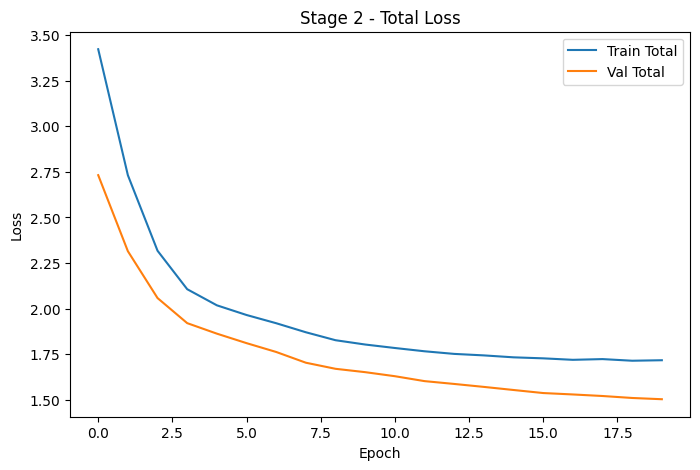

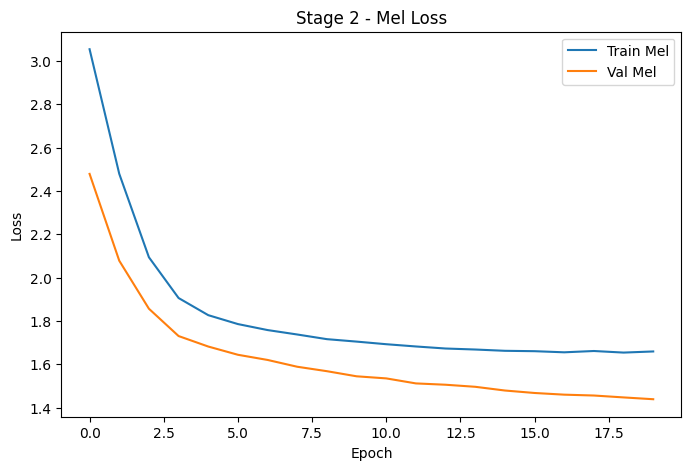

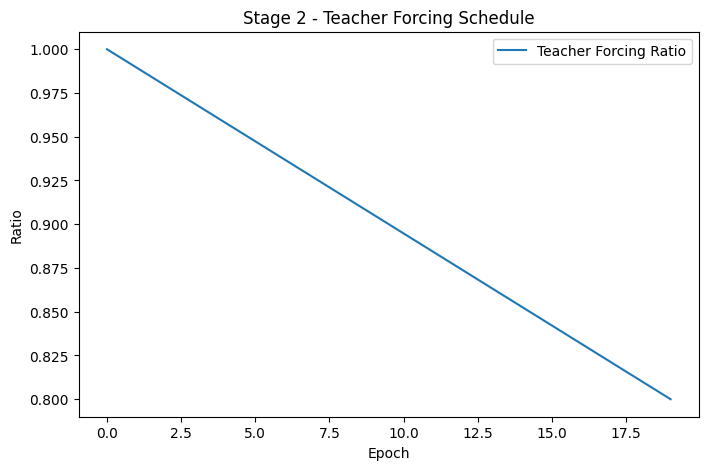

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_total"], label="Train Total")
plt.plot(history["val_total"], label="Val Total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 2 - Total Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_mel"], label="Train Mel")
plt.plot(history["val_mel"], label="Val Mel")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 2 - Mel Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["teacher_forcing"], label="Teacher Forcing Ratio")
plt.xlabel("Epoch")
plt.ylabel("Ratio")
plt.title("Stage 2 - Teacher Forcing Schedule")
plt.legend()
plt.show()

In [21]:
test_text = "hello how are you today"

result = synthesize_mel(
    model,
    test_text,
    max_steps=200,
    stop_threshold=0.5,
    min_decoder_steps=10
)

print("Phoneme sequence:")
print(result["phonemes"])

audio = mel_to_audio_griffinlim(result["mel_post"])
out_path = os.path.join(WORKING_DIR, "stage2_tts_test.wav")
sf.write(out_path, audio, SAMPLE_RATE)

print("Saved:", out_path)
print("Audio length (sec):", len(audio) / SAMPLE_RATE)

Phoneme sequence:
hello how are you today
Saved: /kaggle/working/stage2_tts_test.wav
Audio length (sec): 4.632380952380952


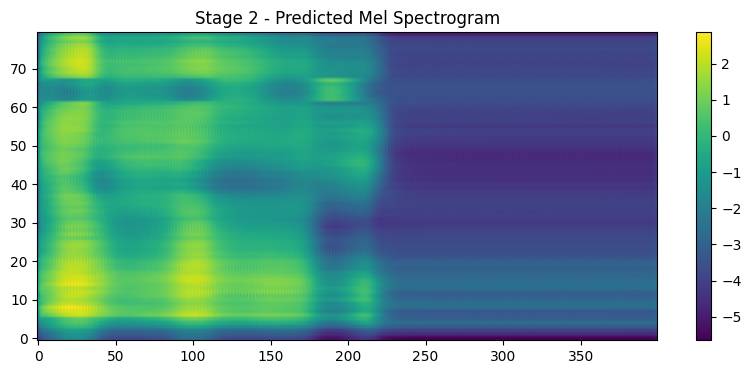

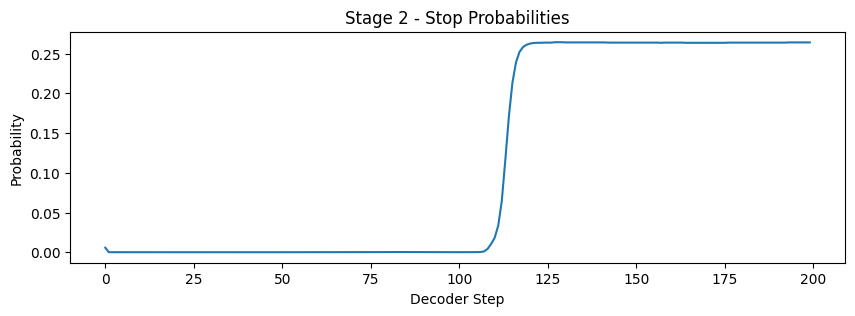

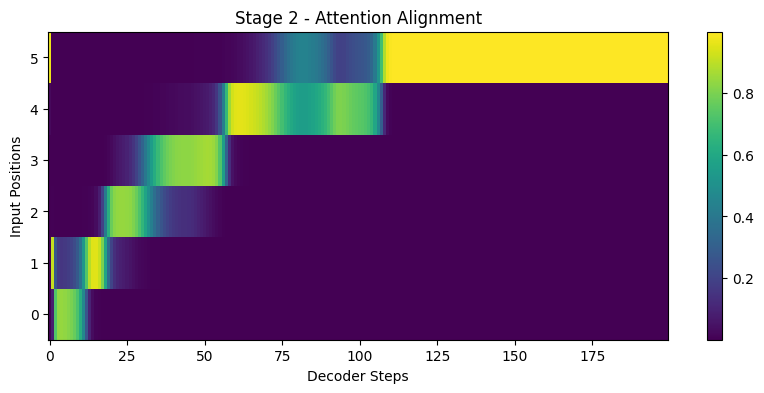

In [22]:
plt.figure(figsize=(10, 4))
plt.imshow(result["mel_post"], aspect="auto", origin="lower")
plt.title("Stage 2 - Predicted Mel Spectrogram")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(result["stop_probs"])
plt.title("Stage 2 - Stop Probabilities")
plt.xlabel("Decoder Step")
plt.ylabel("Probability")
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(result["attn"].T, aspect="auto", origin="lower")
plt.title("Stage 2 - Attention Alignment")
plt.xlabel("Decoder Steps")
plt.ylabel("Input Positions")
plt.colorbar()
plt.show()

In [23]:
Audio(out_path)

STAGE 3 

In [7]:
!pip -q install phonemizer unidecode librosa soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 25.1 MB/s eta 0:00:00


In [8]:
import os
import re
import gc
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
import librosa
import soundfile as sf

from unidecode import unidecode
from phonemizer import phonemize
from IPython.display import Audio

In [9]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi
else:
    print("Enable GPU from Kaggle: Settings -> Accelerator -> GPU")

CUDA available: True
GPU: Tesla T4
Mon Mar 23 19:25:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

WORKING_DIR = "/kaggle/working"
CKPT_DIR = os.path.join(WORKING_DIR, "tts_checkpoints_stage3")
CACHE_DIR = os.path.join(WORKING_DIR, "tts_cache_stage3")
SAMPLES_DIR = os.path.join(WORKING_DIR, "tts_samples_stage3")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)

PHONEME_CACHE_PATH = os.path.join(CACHE_DIR, "ljspeech_phonemes_cached.csv")

candidate_roots = []
for root, dirs, files in os.walk("/kaggle/input"):
    if "metadata.csv" in files and "wavs" in dirs:
        candidate_roots.append(root)

if len(candidate_roots) == 0:
    raise FileNotFoundError(
        "Could not find LJSpeech under /kaggle/input. "
        "Please attach the dataset rahulbhalley/ljspeech11 first."
    )

print("Found dataset candidates:")
for p in candidate_roots:
    print(" -", p)

LJSPEECH_PATH = candidate_roots[0]
CSV_PATH = os.path.join(LJSPEECH_PATH, "metadata.csv")
WAVS_DIR = os.path.join(LJSPEECH_PATH, "wavs")

print("\nUsing:", LJSPEECH_PATH)

# Audio
SAMPLE_RATE = 22050
N_FFT = 1024
HOP_LENGTH = 256
WIN_LENGTH = 1024
N_MELS = 80

# Stage 3 model
EMBED_DIM = 128
ENC_HIDDEN = 128
DEC_HIDDEN = 128
PRENET_DIM = 128
POSTNET_DIM = 96
POSTNET_KERNEL = 5
POSTNET_LAYERS = 3
ATTN_DIM = 128
REDUCTION_FACTOR = 2

# Stage 3 training
BATCH_SIZE = 8
EPOCHS = 25
LR = 2e-4

MAX_TEXT_LEN = 120
MAX_MEL_LEN = 400

TEACHER_FORCING_START = 1.0
TEACHER_FORCING_END = 0.75

GUIDED_ATTENTION_LAMBDA = 2.0
STOP_LOSS_WEIGHT = 1.0
MEL_LOSS_WEIGHT = 1.0
GRAD_CLIP = 1.0

USE_MIXED_PRECISION = torch.cuda.is_available()
NUM_WORKERS = 0
EARLY_STOPPING_PATIENCE = 6

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore")

Device: cuda
Found dataset candidates:
 - /kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1

Using: /kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1


In [11]:
def clean_text(text):
    text = unidecode(str(text).lower().strip())
    text = re.sub(r"[^a-z'.,!?;:()\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def safe_phonemize_batch(text_list, batch_size=128):
    outputs = []
    for start in range(0, len(text_list), batch_size):
        batch = text_list[start:start + batch_size]
        try:
            ph_batch = phonemize(
                batch,
                language="en-us",
                backend="espeak",
                strip=True,
                preserve_punctuation=True,
                with_stress=True
            )
            ph_batch = [
                re.sub(r"\s+", " ", p).strip() if len(str(p).strip()) > 0 else t
                for p, t in zip(ph_batch, batch)
            ]
        except Exception:
            ph_batch = batch

        outputs.extend(ph_batch)

        if start % 1024 == 0:
            print(f"Phonemized {start}/{len(text_list)}")
            gc.collect()

    return outputs

metadata = pd.read_csv(CSV_PATH, sep="|", header=None, names=["id", "raw_text", "normalized"])
metadata["text"] = metadata["normalized"].apply(clean_text)
metadata = metadata[metadata["text"].str.len() > 0].reset_index(drop=True)

if os.path.exists(PHONEME_CACHE_PATH):
    print("Loading phoneme cache...")
    metadata = pd.read_csv(PHONEME_CACHE_PATH)
else:
    print("Creating phoneme cache...")
    texts = metadata["text"].tolist()
    phonemes = safe_phonemize_batch(texts, batch_size=128)
    metadata["phonemes"] = phonemes
    metadata.to_csv(PHONEME_CACHE_PATH, index=False)
    print("Saved phoneme cache to:", PHONEME_CACHE_PATH)

metadata = metadata[(metadata["phonemes"].notna()) & (metadata["phonemes"].str.len() > 0)].reset_index(drop=True)
print("Dataset size after phonemization:", len(metadata))
metadata.head()

Creating phoneme cache...
Phonemized 0/13100
Phonemized 1024/13100
Phonemized 2048/13100
Phonemized 3072/13100
Phonemized 4096/13100
Phonemized 5120/13100
Phonemized 6144/13100
Phonemized 7168/13100
Phonemized 8192/13100
Phonemized 9216/13100
Phonemized 10240/13100
Phonemized 11264/13100
Phonemized 12288/13100
Saved phoneme cache to: /kaggle/working/tts_cache_stage3/ljspeech_phonemes_cached.csv
Dataset size after phonemization: 13100


,id,raw_text,normalized,text,phonemes
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ...","printing, in the only sense with which we are ...","printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...,for although the chinese took impressions from...,for although the chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed...","produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


In [12]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=1.0
)

def load_wav(path):
    wav, sr = torchaudio.load(path)
    wav = wav.mean(dim=0)
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    return wav

def wav_to_mel(wav):
    mel = mel_transform(wav)
    mel = torch.log(torch.clamp(mel, min=1e-5))
    return mel.transpose(0, 1)

def get_approx_mel_len(wav_path):
    wav = load_wav(wav_path)
    return math.ceil(len(wav) / HOP_LENGTH)

In [13]:
PAD = "<pad>"
SOS = "<sos>"
EOS = "<eos>"

def phoneme_to_tokens(ph):
    return ph.split()

all_tokens = []
for ph in metadata["phonemes"]:
    all_tokens.extend(phoneme_to_tokens(ph))

unique_tokens = sorted(set(all_tokens))
vocab = [PAD, SOS, EOS] + unique_tokens

stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}

PAD_ID = stoi[PAD]
SOS_ID = stoi[SOS]
EOS_ID = stoi[EOS]

def seq_to_ids(seq):
    toks = phoneme_to_tokens(seq)
    return [SOS_ID] + [stoi[t] for t in toks if t in stoi] + [EOS_ID]

def ids_to_seq(ids):
    toks = []
    for i in ids:
        tok = itos.get(int(i), "")
        if tok in [PAD, SOS, EOS]:
            continue
        toks.append(tok)
    return " ".join(toks)

metadata["input_ids"] = metadata["phonemes"].apply(seq_to_ids)
metadata["input_len"] = metadata["input_ids"].apply(len)

print("Vocab size:", len(vocab))
metadata[["text", "phonemes", "input_len"]].head()

Vocab size: 22426


,text,phonemes,input_len
0,"printing, in the only sense with which we are ...","printing, in the only sense with which we are ...",29
1,in being comparatively modern.,in being comparatively modern.,6
2,for although the chinese took impressions from...,for although the chinese took impressions from...,26
3,"produced the block books, which were the immed...","produced the block books, which were the immed...",16
4,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,27


In [14]:
metadata = metadata[metadata["input_len"] <= 100].reset_index(drop=True)

keep_rows = []
for i, row in metadata.iterrows():
    wav_path = os.path.join(WAVS_DIR, row["id"] + ".wav")
    approx_mel_len = get_approx_mel_len(wav_path)
    if approx_mel_len <= MAX_MEL_LEN:
        keep_rows.append(i)

metadata = metadata.iloc[keep_rows].reset_index(drop=True)

metadata = metadata.sample(n=min(5000, len(metadata)), random_state=42).reset_index(drop=True)

print("Stage 3 dataset size:", len(metadata))
metadata[["text", "phonemes", "input_len"]].head()

Stage 3 dataset size: 2796


,text,phonemes,input_len
0,"three years later came the case of dr. smethurst,","three years later came the case of dr. smethurst,",11
1,"as marguerite oswald testified, quote,","as marguerite oswald testified, quote,",7
2,"the latter unsexed and brutalized by dissipation,","the latter unsexed and brutalized by dissipation,",9
3,from august nineteen sixty-two,from august nineteen sixty-two,6
4,were blocked by persons who had overflowed fro...,were blocked by persons who had overflowed fro...,17


In [15]:
indices = list(range(len(metadata)))
random.shuffle(indices)

split = int(0.9 * len(indices))
train_idx = indices[:split]
val_idx = indices[split:]

train_df = metadata.iloc[train_idx].reset_index(drop=True)
val_df = metadata.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 2516
Val: 280


In [16]:
class LJSpeechTTSDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav_path = os.path.join(WAVS_DIR, row["id"] + ".wav")

        wav = load_wav(wav_path)
        mel = wav_to_mel(wav)

        if len(mel) > MAX_MEL_LEN:
            mel = mel[:MAX_MEL_LEN]

        inp = torch.tensor(row["input_ids"], dtype=torch.long)
        return inp, mel

def collate_fn(batch):
    inputs, mels = zip(*batch)

    input_lens = torch.tensor([len(x) for x in inputs], dtype=torch.long)
    mel_lens = torch.tensor([len(x) for x in mels], dtype=torch.long)

    max_input_len = max(input_lens).item()
    max_mel_len = max(mel_lens).item()

    padded_inputs = torch.full((len(batch), max_input_len), PAD_ID, dtype=torch.long)
    padded_mels = torch.zeros((len(batch), max_mel_len, N_MELS), dtype=torch.float32)
    stop_targets = torch.zeros((len(batch), max_mel_len), dtype=torch.float32)

    for i, (inp, mel) in enumerate(zip(inputs, mels)):
        padded_inputs[i, :len(inp)] = inp
        padded_mels[i, :len(mel)] = mel
        stop_targets[i, len(mel)-1:] = 1.0

    return padded_inputs, input_lens, padded_mels, mel_lens, stop_targets

train_ds = LJSpeechTTSDataset(train_df)
val_ds = LJSpeechTTSDataset(val_df)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

sample_batch = next(iter(train_loader))
for item in sample_batch:
    print(item.shape if hasattr(item, "shape") else item)

torch.Size([8, 16])
torch.Size([8])
torch.Size([8, 397, 80])
torch.Size([8])
torch.Size([8, 397])


In [17]:
class Prenet(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=0.5, training=self.training)
        return x

class LocationAwareAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim, attn_dim=128, conv_channels=32, conv_kernel=31):
        super().__init__()
        self.W_enc = nn.Linear(enc_dim, attn_dim, bias=False)
        self.W_dec = nn.Linear(dec_dim, attn_dim, bias=False)
        self.W_loc = nn.Linear(conv_channels, attn_dim, bias=False)
        self.location_conv = nn.Conv1d(
            in_channels=1,
            out_channels=conv_channels,
            kernel_size=conv_kernel,
            padding=(conv_kernel - 1) // 2,
            bias=False
        )
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, encoder_outputs, decoder_hidden, prev_attn=None, mask=None):
        B, T_enc, _ = encoder_outputs.shape

        if prev_attn is None:
            prev_attn = torch.zeros(B, T_enc, device=encoder_outputs.device)
            prev_attn[:, 0] = 1.0

        loc_feat = self.location_conv(prev_attn.unsqueeze(1))     # [B, C, T]
        loc_feat = loc_feat.transpose(1, 2)                       # [B, T, C]

        enc_proj = self.W_enc(encoder_outputs)
        dec_proj = self.W_dec(decoder_hidden).unsqueeze(1)
        loc_proj = self.W_loc(loc_feat)

        energy = self.v(torch.tanh(enc_proj + dec_proj + loc_proj)).squeeze(-1)

        if mask is not None:
            energy = energy.masked_fill(mask == 0, -1e4)

        attn_weights = torch.softmax(energy, dim=-1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn_weights

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        outputs, _ = self.lstm(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        return outputs

class Postnet(nn.Module):
    def __init__(self, mel_dim, postnet_dim=96, kernel_size=5, num_layers=3):
        super().__init__()
        layers = []

        layers.append(nn.Sequential(
            nn.Conv1d(mel_dim, postnet_dim, kernel_size, padding=(kernel_size - 1)//2),
            nn.BatchNorm1d(postnet_dim),
            nn.Tanh(),
            nn.Dropout(0.5)
        ))

        for _ in range(num_layers - 2):
            layers.append(nn.Sequential(
                nn.Conv1d(postnet_dim, postnet_dim, kernel_size, padding=(kernel_size - 1)//2),
                nn.BatchNorm1d(postnet_dim),
                nn.Tanh(),
                nn.Dropout(0.5)
            ))

        layers.append(nn.Sequential(
            nn.Conv1d(postnet_dim, mel_dim, kernel_size, padding=(kernel_size - 1)//2),
            nn.BatchNorm1d(mel_dim),
            nn.Dropout(0.5)
        ))

        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        x = x.transpose(1, 2)
        for layer in self.layers:
            x = layer(x)
        x = x.transpose(1, 2)
        return x

class Decoder(nn.Module):
    def __init__(self, mel_dim, enc_dim, dec_hidden, prenet_dim, reduction_factor=2):
        super().__init__()
        self.reduction_factor = reduction_factor
        self.prenet = Prenet(mel_dim * reduction_factor, prenet_dim)
        self.lstm_cell = nn.LSTMCell(prenet_dim + enc_dim, dec_hidden)
        self.attention = LocationAwareAttention(enc_dim, dec_hidden, attn_dim=ATTN_DIM)
        self.mel_proj = nn.Linear(dec_hidden + enc_dim, mel_dim * reduction_factor)
        self.stop_proj = nn.Linear(dec_hidden + enc_dim, 1)

    def forward_step(self, prev_mel, hidden, cell, encoder_outputs, enc_mask, prev_attn):
        prenet_out = self.prenet(prev_mel)
        context, attn = self.attention(encoder_outputs, hidden, prev_attn=prev_attn, mask=enc_mask)

        decoder_input = torch.cat([prenet_out, context], dim=-1)
        hidden, cell = self.lstm_cell(decoder_input, (hidden, cell))

        proj_input = torch.cat([hidden, context], dim=-1)
        mel_out = self.mel_proj(proj_input)
        stop_logit = self.stop_proj(proj_input).squeeze(-1)

        return mel_out, stop_logit, hidden, cell, attn

class Stage3TTS(nn.Module):
    def __init__(self, vocab_size, embed_dim, enc_hidden, dec_hidden, mel_dim, prenet_dim, reduction_factor=2):
        super().__init__()
        self.mel_dim = mel_dim
        self.reduction_factor = reduction_factor
        self.encoder = Encoder(vocab_size, embed_dim, enc_hidden)
        self.decoder = Decoder(mel_dim, enc_hidden * 2, dec_hidden, prenet_dim, reduction_factor=reduction_factor)
        self.enc_to_dec = nn.Linear(enc_hidden * 2, dec_hidden)
        self.postnet = Postnet(
            mel_dim=mel_dim,
            postnet_dim=POSTNET_DIM,
            kernel_size=POSTNET_KERNEL,
            num_layers=POSTNET_LAYERS
        )

    def make_mask(self, lengths, max_len):
        ids = torch.arange(max_len, device=lengths.device).unsqueeze(0)
        return (ids < lengths.unsqueeze(1)).int()

    def forward(
        self,
        inputs,
        input_lens,
        target_mels=None,
        teacher_forcing_ratio=1.0,
        max_decoder_steps=250,
        stop_threshold=0.5,
        min_decoder_steps=10
    ):
        encoder_outputs = self.encoder(inputs, input_lens)
        B, T_enc, enc_dim = encoder_outputs.shape
        enc_mask = self.make_mask(input_lens, T_enc)

        mean_enc = encoder_outputs.mean(dim=1)
        hidden = torch.tanh(self.enc_to_dec(mean_enc))
        cell = torch.zeros_like(hidden)

        prev_mel = torch.zeros(B, self.mel_dim * self.reduction_factor, device=inputs.device)
        prev_attn = None

        mel_outputs = []
        stop_outputs = []
        alignments = []

        if target_mels is not None:
            T_target = target_mels.size(1)
            T_out = math.ceil(T_target / self.reduction_factor)
        else:
            T_out = max_decoder_steps

        finished = torch.zeros(B, dtype=torch.bool, device=inputs.device)

        for t in range(T_out):
            mel_chunk, stop_logit, hidden, cell, attn = self.decoder.forward_step(
                prev_mel, hidden, cell, encoder_outputs, enc_mask, prev_attn
            )

            prev_attn = attn

            mel_outputs.append(mel_chunk.unsqueeze(1))
            stop_outputs.append(stop_logit.unsqueeze(1))
            alignments.append(attn.unsqueeze(1))

            if target_mels is not None and random.random() < teacher_forcing_ratio:
                start = t * self.reduction_factor
                end = min(start + self.reduction_factor, target_mels.size(1))
                teacher_chunk = torch.zeros(B, self.mel_dim * self.reduction_factor, device=inputs.device)
                actual = target_mels[:, start:end, :].reshape(B, -1)
                teacher_chunk[:, :actual.size(1)] = actual
                prev_mel = teacher_chunk
            else:
                prev_mel = mel_chunk

            if target_mels is None:
                stop_prob = torch.sigmoid(stop_logit)
                finished = finished | ((stop_prob > stop_threshold) & (t >= min_decoder_steps))
                if finished.all():
                    break

        mel_outputs = torch.cat(mel_outputs, dim=1)
        stop_outputs = torch.cat(stop_outputs, dim=1)
        alignments = torch.cat(alignments, dim=1)

        mel_outputs = mel_outputs.view(B, -1, self.mel_dim)
        mel_post = mel_outputs + self.postnet(mel_outputs)

        return mel_outputs, mel_post, stop_outputs, alignments

In [18]:
def make_nonpad_mask(lengths, max_len):
    ids = torch.arange(max_len, device=lengths.device).unsqueeze(0)
    return ids < lengths.unsqueeze(1)

def masked_l1_loss(pred, target, lengths):
    B, T, D = pred.shape
    max_t = min(pred.size(1), target.size(1))
    pred = pred[:, :max_t, :]
    target = target[:, :max_t, :]
    clipped_lengths = torch.clamp(lengths, max=max_t)

    mask = make_nonpad_mask(clipped_lengths, max_t).unsqueeze(-1).float()
    loss = torch.abs(pred - target) * mask
    return loss.sum() / (mask.sum() * D + 1e-8)

def masked_bce_loss(stop_logits, stop_targets, lengths, reduction_factor=2):
    reduced_lengths = torch.ceil(lengths.float() / reduction_factor).long()
    T = stop_logits.shape[1]

    reduced_targets = torch.zeros_like(stop_logits)
    for b in range(stop_logits.size(0)):
        stop_idx = max(reduced_lengths[b].item() - 1, 0)
        reduced_targets[b, stop_idx:] = 1.0

    mask = make_nonpad_mask(reduced_lengths, T).float()
    loss = F.binary_cross_entropy_with_logits(stop_logits, reduced_targets, reduction="none")
    loss = loss * mask
    return loss.sum() / (mask.sum() + 1e-8)

def guided_attention_loss(attn, input_lens, mel_lens, reduction_factor=2, g=0.2):
    B, T_dec_max, T_enc_max = attn.shape
    total_loss = 0.0
    count = 0

    for b in range(B):
        T_dec = math.ceil(mel_lens[b].item() / reduction_factor)
        T_enc = input_lens[b].item()

        if T_dec <= 1 or T_enc <= 1:
            continue

        t = torch.arange(T_dec, device=attn.device).unsqueeze(1).float() / T_dec
        n = torch.arange(T_enc, device=attn.device).unsqueeze(0).float() / T_enc

        W = 1.0 - torch.exp(-((n - t) ** 2) / (2 * g * g))
        A = attn[b, :T_dec, :T_enc]

        total_loss += torch.mean(A * W)
        count += 1

    if count == 0:
        return torch.tensor(0.0, device=attn.device)

    return total_loss / count

def compute_total_loss(mel_pred, mel_post, mel_target, stop_logits, stop_targets, attn, input_lens, mel_lens, reduction_factor=2):
    mel_loss_1 = masked_l1_loss(mel_pred, mel_target, mel_lens)
    mel_loss_2 = masked_l1_loss(mel_post, mel_target, mel_lens)
    mel_loss = mel_loss_1 + mel_loss_2

    stop_loss = masked_bce_loss(stop_logits, stop_targets, mel_lens, reduction_factor=reduction_factor)
    attn_loss = guided_attention_loss(attn, input_lens, mel_lens, reduction_factor=reduction_factor)

    total = (
        MEL_LOSS_WEIGHT * mel_loss
        + STOP_LOSS_WEIGHT * stop_loss
        + GUIDED_ATTENTION_LAMBDA * attn_loss
    )

    return total, mel_loss, stop_loss, attn_loss

In [19]:
model = Stage3TTS(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    enc_hidden=ENC_HIDDEN,
    dec_hidden=DEC_HIDDEN,
    mel_dim=N_MELS,
    prenet_dim=PRENET_DIM,
    reduction_factor=REDUCTION_FACTOR
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = torch.amp.GradScaler("cuda", enabled=USE_MIXED_PRECISION)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", num_params)

Trainable params: 3707953


In [20]:
def save_checkpoint(path, model, optimizer, scaler, epoch, train_loss, val_loss):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "vocab": vocab,
        "stoi": stoi,
        "itos": itos
    }, path)

def load_checkpoint(path, model, optimizer=None, scaler=None, map_location=device):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scaler is not None and ckpt.get("scaler_state") is not None:
        scaler.load_state_dict(ckpt["scaler_state"])
    return ckpt

In [21]:
def text_to_input_ids(text):
    text = clean_text(text)

    try:
        ph = phonemize(
            [text],
            language="en-us",
            backend="espeak",
            strip=True,
            preserve_punctuation=True,
            with_stress=True
        )[0]
        ph = re.sub(r"\s+", " ", ph).strip()
        if len(ph) == 0:
            ph = text
    except Exception:
        ph = text

    toks = ph.split()
    ids = [SOS_ID] + [stoi[t] for t in toks if t in stoi] + [EOS_ID]
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0), ph

@torch.no_grad()
def synthesize_mel(model, text, max_steps=250, stop_threshold=0.4, min_decoder_steps=10):
    model.eval()

    x, ph = text_to_input_ids(text)
    x = x.to(device)
    x_len = torch.tensor([x.size(1)], dtype=torch.long, device=device)

    with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
        mel_pred, mel_post, stop_logits, attn = model(
            x,
            x_len,
            target_mels=None,
            teacher_forcing_ratio=0.0,
            max_decoder_steps=max_steps,
            stop_threshold=stop_threshold,
            min_decoder_steps=min_decoder_steps
        )

    mel_post = mel_post.squeeze(0).cpu().float().numpy().T
    stop_probs = torch.sigmoid(stop_logits).squeeze(0).cpu().float().numpy()
    attn = attn.squeeze(0).cpu().float().numpy()

    return {
        "phonemes": ph,
        "mel_post": mel_post,
        "stop_probs": stop_probs,
        "attn": attn
    }

def mel_to_audio_griffinlim(mel_log):
    mel = np.exp(mel_log)
    audio = librosa.feature.inverse.mel_to_audio(
        mel,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        power=1.0,
        n_iter=60
    )
    return audio

def get_teacher_forcing_ratio(epoch, total_epochs, start=1.0, end=0.75):
    if total_epochs <= 1:
        return end
    alpha = (epoch - 1) / (total_epochs - 1)
    return start + alpha * (end - start)

@torch.no_grad()
def save_epoch_sample(model, epoch, text="hello how are you today"):
    model.eval()
    result = synthesize_mel(
        model,
        text,
        max_steps=250,
        stop_threshold=0.4,
        min_decoder_steps=10
    )

    audio = mel_to_audio_griffinlim(result["mel_post"])
    audio_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:02d}.wav")
    sf.write(audio_path, audio, SAMPLE_RATE)

    plt.figure(figsize=(10, 4))
    plt.imshow(result["attn"].T, aspect="auto", origin="lower")
    plt.title(f"Attention Alignment - Epoch {epoch}")
    plt.xlabel("Decoder Steps")
    plt.ylabel("Input Positions")
    plt.colorbar()
    plt.tight_layout()
    plot_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:02d}_attn.png")
    plt.savefig(plot_path)
    plt.close()

    print("Saved sample audio:", audio_path)
    print("Saved attention plot:", plot_path)

In [22]:
def evaluate(model, loader):
    model.eval()
    total_loss_sum = 0.0
    mel_sum = 0.0
    stop_sum = 0.0
    attn_sum = 0.0
    total_items = 0

    with torch.no_grad():
        for inputs, input_lens, mels, mel_lens, stop_targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            input_lens = input_lens.to(device, non_blocking=True)
            mels = mels.to(device, non_blocking=True)
            mel_lens = mel_lens.to(device, non_blocking=True)
            stop_targets = stop_targets.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
                mel_pred, mel_post, stop_logits, attn = model(
                    inputs,
                    input_lens,
                    target_mels=mels,
                    teacher_forcing_ratio=1.0
                )

                total_loss, mel_loss, stop_loss, attn_loss = compute_total_loss(
                    mel_pred, mel_post, mels, stop_logits, stop_targets, attn, input_lens, mel_lens,
                    reduction_factor=REDUCTION_FACTOR
                )

            bs = inputs.size(0)
            total_loss_sum += total_loss.item() * bs
            mel_sum += mel_loss.item() * bs
            stop_sum += stop_loss.item() * bs
            attn_sum += attn_loss.item() * bs
            total_items += bs

    return {
        "total": total_loss_sum / total_items,
        "mel": mel_sum / total_items,
        "stop": stop_sum / total_items,
        "attn": attn_sum / total_items
    }

In [23]:
def evaluate(model, loader):
    model.eval()
    total_loss_sum = 0.0
    mel_sum = 0.0
    stop_sum = 0.0
    attn_sum = 0.0
    total_items = 0

    with torch.no_grad():
        for inputs, input_lens, mels, mel_lens, stop_targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            input_lens = input_lens.to(device, non_blocking=True)
            mels = mels.to(device, non_blocking=True)
            mel_lens = mel_lens.to(device, non_blocking=True)
            stop_targets = stop_targets.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
                mel_pred, mel_post, stop_logits, attn = model(
                    inputs,
                    input_lens,
                    target_mels=mels,
                    teacher_forcing_ratio=1.0
                )

                total_loss, mel_loss, stop_loss, attn_loss = compute_total_loss(
                    mel_pred, mel_post, mels, stop_logits, stop_targets, attn, input_lens, mel_lens,
                    reduction_factor=REDUCTION_FACTOR
                )

            bs = inputs.size(0)
            total_loss_sum += total_loss.item() * bs
            mel_sum += mel_loss.item() * bs
            stop_sum += stop_loss.item() * bs
            attn_sum += attn_loss.item() * bs
            total_items += bs

    return {
        "total": total_loss_sum / total_items,
        "mel": mel_sum / total_items,
        "stop": stop_sum / total_items,
        "attn": attn_sum / total_items
    }

In [24]:
best_val = float("inf")
epochs_without_improvement = 0

history = {
    "train_total": [],
    "val_total": [],
    "train_mel": [],
    "val_mel": [],
    "train_stop": [],
    "val_stop": [],
    "train_attn": [],
    "val_attn": [],
    "teacher_forcing": []
}

for epoch in range(1, EPOCHS + 1):
    model.train()

    teacher_forcing_ratio = get_teacher_forcing_ratio(
        epoch,
        EPOCHS,
        start=TEACHER_FORCING_START,
        end=TEACHER_FORCING_END
    )

    train_total_sum = 0.0
    train_mel_sum = 0.0
    train_stop_sum = 0.0
    train_attn_sum = 0.0
    total_items = 0

    for inputs, input_lens, mels, mel_lens, stop_targets in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        input_lens = input_lens.to(device, non_blocking=True)
        mels = mels.to(device, non_blocking=True)
        mel_lens = mel_lens.to(device, non_blocking=True)
        stop_targets = stop_targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
            mel_pred, mel_post, stop_logits, attn = model(
                inputs,
                input_lens,
                target_mels=mels,
                teacher_forcing_ratio=teacher_forcing_ratio
            )

            total_loss, mel_loss, stop_loss, attn_loss = compute_total_loss(
                mel_pred, mel_post, mels, stop_logits, stop_targets, attn, input_lens, mel_lens,
                reduction_factor=REDUCTION_FACTOR
            )

        if not torch.isfinite(total_loss):
            print("Skipping batch because loss is NaN/Inf")
            continue

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        bs = inputs.size(0)
        train_total_sum += total_loss.item() * bs
        train_mel_sum += mel_loss.item() * bs
        train_stop_sum += stop_loss.item() * bs
        train_attn_sum += attn_loss.item() * bs
        total_items += bs

    if total_items == 0:
        raise RuntimeError("No valid training batches were processed.")

    train_metrics = {
        "total": train_total_sum / total_items,
        "mel": train_mel_sum / total_items,
        "stop": train_stop_sum / total_items,
        "attn": train_attn_sum / total_items
    }

    val_metrics = evaluate(model, val_loader)

    history["train_total"].append(train_metrics["total"])
    history["val_total"].append(val_metrics["total"])
    history["train_mel"].append(train_metrics["mel"])
    history["val_mel"].append(val_metrics["mel"])
    history["train_stop"].append(train_metrics["stop"])
    history["val_stop"].append(val_metrics["stop"])
    history["train_attn"].append(train_metrics["attn"])
    history["val_attn"].append(val_metrics["attn"])
    history["teacher_forcing"].append(teacher_forcing_ratio)

    print(
        f"Epoch {epoch:02d} | "
        f"TF {teacher_forcing_ratio:.3f} | "
        f"Train Total {train_metrics['total']:.4f} | Val Total {val_metrics['total']:.4f} | "
        f"Train Mel {train_metrics['mel']:.4f} | Val Mel {val_metrics['mel']:.4f} | "
        f"Train Stop {train_metrics['stop']:.4f} | Val Stop {val_metrics['stop']:.4f} | "
        f"Train Attn {train_metrics['attn']:.4f} | Val Attn {val_metrics['attn']:.4f}"
    )

    latest_path = os.path.join(CKPT_DIR, "latest_checkpoint.pt")
    save_checkpoint(latest_path, model, optimizer, scaler, epoch, train_metrics["total"], val_metrics["total"])

    if val_metrics["total"] < best_val:
        best_val = val_metrics["total"]
        epochs_without_improvement = 0

        best_path = os.path.join(CKPT_DIR, "best_checkpoint.pt")
        save_checkpoint(best_path, model, optimizer, scaler, epoch, train_metrics["total"], val_metrics["total"])
        print("Saved best checkpoint.")

        try:
            save_epoch_sample(model, epoch)
        except Exception as e:
            print("Could not save epoch sample:", e)
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

best_path = os.path.join(CKPT_DIR, "best_checkpoint.pt")
if os.path.exists(best_path):
    ckpt = load_checkpoint(best_path, model, optimizer=None, scaler=None)
    print("Restored best checkpoint from epoch:", ckpt["epoch"])

Epoch 01 | TF 1.000 | Train Total 2.8197 | Val Total 2.0286 | Train Mel 2.6182 | Val Mel 1.8814 | Train Stop 0.0904 | Val Stop 0.0433 | Train Attn 0.0555 | Val Attn 0.0520
Saved best checkpoint.
Saved sample audio: /kaggle/working/tts_samples_stage3/epoch_01.wav
Saved attention plot: /kaggle/working/tts_samples_stage3/epoch_01_attn.png
Epoch 02 | TF 0.990 | Train Total 1.9560 | Val Total 1.7365 | Train Mel 1.8309 | Val Mel 1.6338 | Train Stop 0.0322 | Val Stop 0.0236 | Train Attn 0.0464 | Val Attn 0.0396
Saved best checkpoint.
Saved sample audio: /kaggle/working/tts_samples_stage3/epoch_02.wav
Saved attention plot: /kaggle/working/tts_samples_stage3/epoch_02_attn.png
Epoch 03 | TF 0.979 | Train Total 1.7498 | Val Total 1.6037 | Train Mel 1.6809 | Val Mel 1.5466 | Train Stop 0.0230 | Val Stop 0.0213 | Train Attn 0.0229 | Val Attn 0.0179
Saved best checkpoint.
Saved sample audio: /kaggle/working/tts_samples_stage3/epoch_03.wav
Saved attention plot: /kaggle/working/tts_samples_stage3/epoc

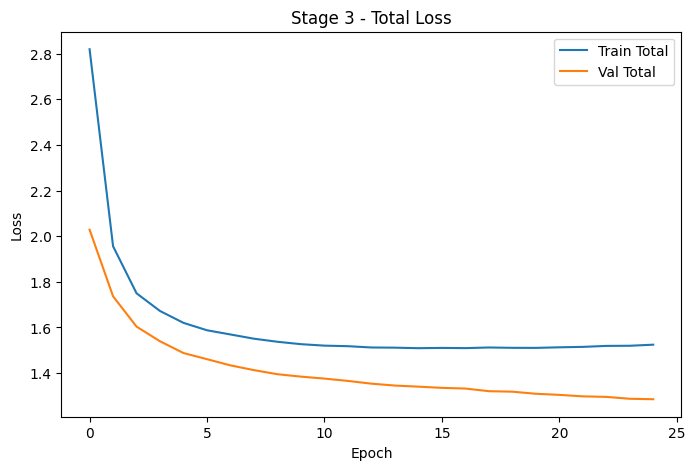

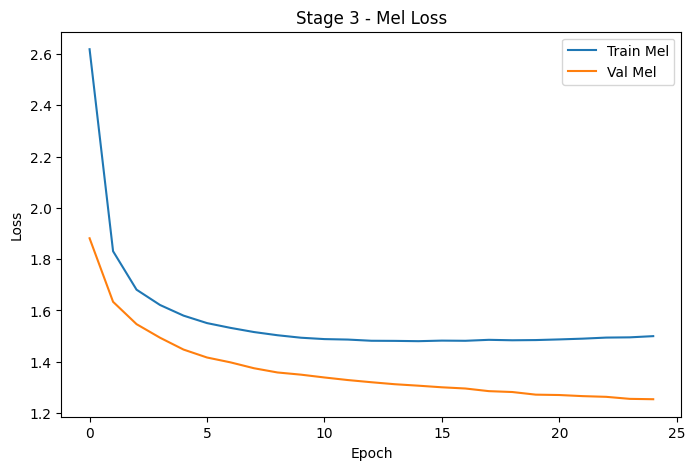

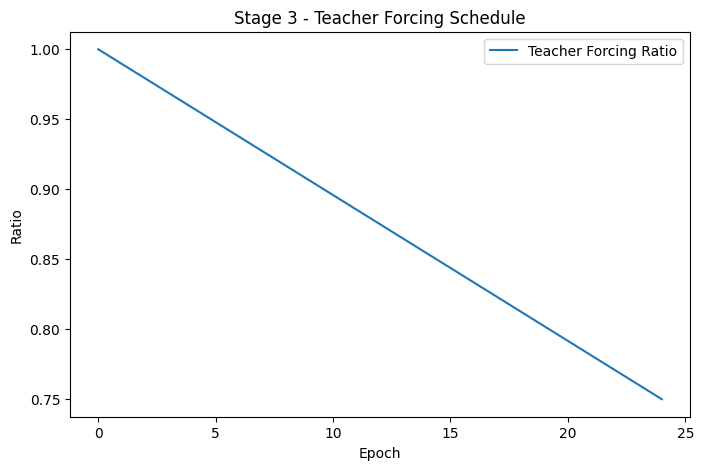

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_total"], label="Train Total")
plt.plot(history["val_total"], label="Val Total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 3 - Total Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_mel"], label="Train Mel")
plt.plot(history["val_mel"], label="Val Mel")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 3 - Mel Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["teacher_forcing"], label="Teacher Forcing Ratio")
plt.xlabel("Epoch")
plt.ylabel("Ratio")
plt.title("Stage 3 - Teacher Forcing Schedule")
plt.legend()
plt.show()

In [26]:
test_text = "hello how are you today"

result = synthesize_mel(
    model,
    test_text,
    max_steps=250,
    stop_threshold=0.4,
    min_decoder_steps=10
)

print("Phoneme sequence:")
print(result["phonemes"])

audio = mel_to_audio_griffinlim(result["mel_post"])
out_path = os.path.join(WORKING_DIR, "stage3_tts_test.wav")
sf.write(out_path, audio, SAMPLE_RATE)

print("Saved:", out_path)
print("Audio length (sec):", len(audio) / SAMPLE_RATE)

Phoneme sequence:
hello how are you today
Saved: /kaggle/working/stage3_tts_test.wav
Audio length (sec): 5.793378684807256


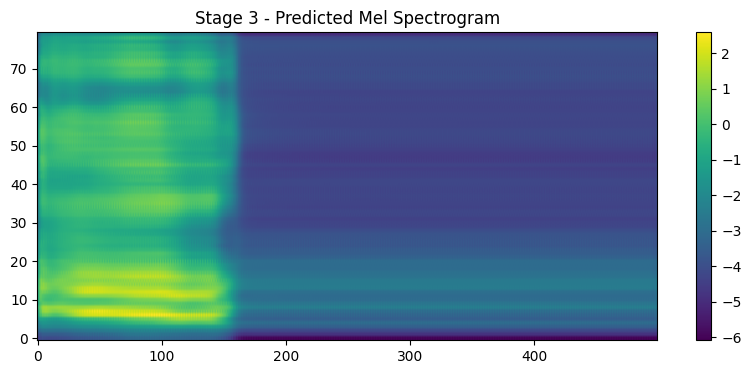

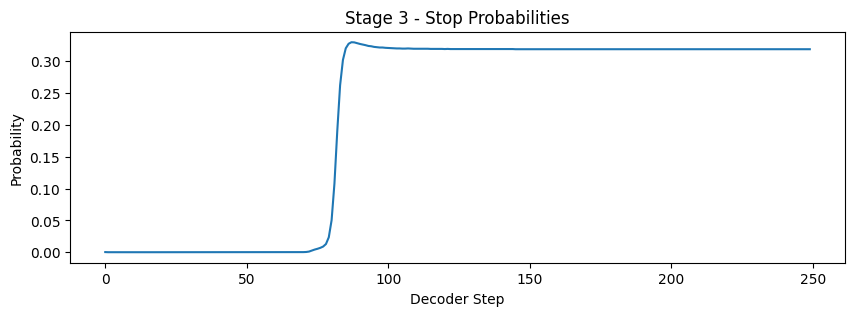

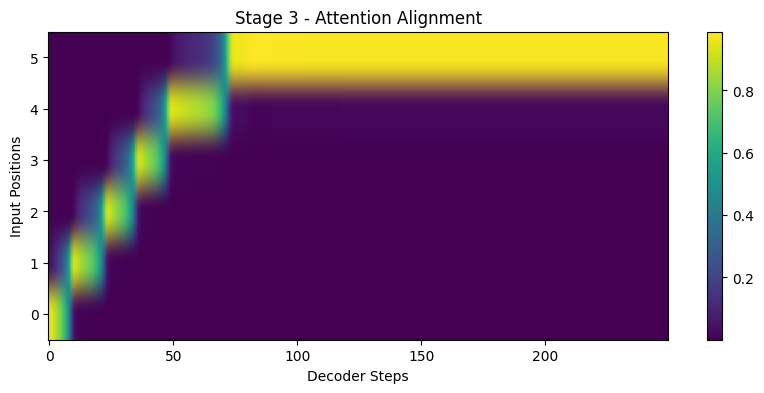

In [27]:
plt.figure(figsize=(10, 4))
plt.imshow(result["mel_post"], aspect="auto", origin="lower")
plt.title("Stage 3 - Predicted Mel Spectrogram")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(result["stop_probs"])
plt.title("Stage 3 - Stop Probabilities")
plt.xlabel("Decoder Step")
plt.ylabel("Probability")
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(result["attn"].T, aspect="auto", origin="lower")
plt.title("Stage 3 - Attention Alignment")
plt.xlabel("Decoder Steps")
plt.ylabel("Input Positions")
plt.colorbar()
plt.show()

In [28]:
Audio(out_path)

**STAGE 4**

In [1]:
!pip -q install phonemizer unidecode librosa soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 22.5 MB/s eta 0:00:00


In [2]:
import os
import re
import gc
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
import librosa
import soundfile as sf

from unidecode import unidecode
from phonemizer import phonemize
from IPython.display import Audio

In [3]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi
else:
    print("Enable GPU from Kaggle: Settings -> Accelerator -> GPU")

CUDA available: True
GPU: Tesla T4
Mon Mar 23 21:55:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

WORKING_DIR = "/kaggle/working"
CKPT_DIR = os.path.join(WORKING_DIR, "tts_checkpoints_stage4")
CACHE_DIR = os.path.join(WORKING_DIR, "tts_cache_stage4")
SAMPLES_DIR = os.path.join(WORKING_DIR, "tts_samples_stage4")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)

PHONEME_CACHE_PATH = os.path.join(CACHE_DIR, "ljspeech_phonemes_cached.csv")

candidate_roots = []
for root, dirs, files in os.walk("/kaggle/input"):
    if "metadata.csv" in files and "wavs" in dirs:
        candidate_roots.append(root)

if len(candidate_roots) == 0:
    raise FileNotFoundError(
        "Could not find LJSpeech under /kaggle/input. "
        "Please attach the dataset rahulbhalley/ljspeech11 first."
    )

print("Found dataset candidates:")
for p in candidate_roots:
    print(" -", p)

LJSPEECH_PATH = candidate_roots[0]
CSV_PATH = os.path.join(LJSPEECH_PATH, "metadata.csv")
WAVS_DIR = os.path.join(LJSPEECH_PATH, "wavs")

print("\nUsing:", LJSPEECH_PATH)

# Audio
SAMPLE_RATE = 22050
N_FFT = 1024
HOP_LENGTH = 256
WIN_LENGTH = 1024
N_MELS = 80

# Stage 4 model
EMBED_DIM = 160
ENC_HIDDEN = 160
DEC_HIDDEN = 160
PRENET_DIM = 128
POSTNET_DIM = 128
POSTNET_KERNEL = 5
POSTNET_LAYERS = 5
ATTN_DIM = 160
REDUCTION_FACTOR = 2

# Stage 4 training
BATCH_SIZE = 8
EPOCHS = 30
LR = 2e-4
MIN_LR = 5e-5

MAX_TEXT_LEN = 120
MAX_MEL_LEN = 450

TEACHER_FORCING_START = 1.0
TEACHER_FORCING_END = 0.70

GUIDED_ATTENTION_LAMBDA_START = 3.0
GUIDED_ATTENTION_LAMBDA_END = 1.0

STOP_LOSS_WEIGHT = 1.0
STOP_POS_WEIGHT = 8.0
MEL_LOSS_WEIGHT = 1.0
GRAD_CLIP = 1.0

USE_MIXED_PRECISION = torch.cuda.is_available()
NUM_WORKERS = 0
EARLY_STOPPING_PATIENCE = 7

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore")

Device: cuda
Found dataset candidates:
 - /kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1

Using: /kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1


In [5]:
def clean_text(text):
    text = unidecode(str(text).lower().strip())
    text = re.sub(r"[^a-z'.,!?;:()\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def safe_phonemize_batch(text_list, batch_size=128):
    outputs = []
    for start in range(0, len(text_list), batch_size):
        batch = text_list[start:start + batch_size]
        try:
            ph_batch = phonemize(
                batch,
                language="en-us",
                backend="espeak",
                strip=True,
                preserve_punctuation=True,
                with_stress=True
            )
            ph_batch = [
                re.sub(r"\s+", " ", p).strip() if len(str(p).strip()) > 0 else t
                for p, t in zip(ph_batch, batch)
            ]
        except Exception:
            ph_batch = batch

        outputs.extend(ph_batch)

        if start % 1024 == 0:
            print(f"Phonemized {start}/{len(text_list)}")
            gc.collect()

    return outputs

metadata = pd.read_csv(CSV_PATH, sep="|", header=None, names=["id", "raw_text", "normalized"])
metadata["text"] = metadata["normalized"].apply(clean_text)
metadata = metadata[metadata["text"].str.len() > 0].reset_index(drop=True)

if os.path.exists(PHONEME_CACHE_PATH):
    print("Loading phoneme cache...")
    metadata = pd.read_csv(PHONEME_CACHE_PATH)
else:
    print("Creating phoneme cache...")
    texts = metadata["text"].tolist()
    phonemes = safe_phonemize_batch(texts, batch_size=128)
    metadata["phonemes"] = phonemes
    metadata.to_csv(PHONEME_CACHE_PATH, index=False)
    print("Saved phoneme cache to:", PHONEME_CACHE_PATH)

metadata = metadata[(metadata["phonemes"].notna()) & (metadata["phonemes"].str.len() > 0)].reset_index(drop=True)
print("Dataset size after phonemization:", len(metadata))
metadata.head()

Creating phoneme cache...
Phonemized 0/13100
Phonemized 1024/13100
Phonemized 2048/13100
Phonemized 3072/13100
Phonemized 4096/13100
Phonemized 5120/13100
Phonemized 6144/13100
Phonemized 7168/13100
Phonemized 8192/13100
Phonemized 9216/13100
Phonemized 10240/13100
Phonemized 11264/13100
Phonemized 12288/13100
Saved phoneme cache to: /kaggle/working/tts_cache_stage4/ljspeech_phonemes_cached.csv
Dataset size after phonemization: 13100


,id,raw_text,normalized,text,phonemes
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ...","printing, in the only sense with which we are ...","printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...,for although the chinese took impressions from...,for although the chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed...","produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


In [6]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=1.0
)

def load_wav(path):
    wav, sr = torchaudio.load(path)
    wav = wav.mean(dim=0)
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    return wav

def wav_to_mel(wav):
    mel = mel_transform(wav)
    mel = torch.log(torch.clamp(mel, min=1e-5))
    return mel.transpose(0, 1)

def get_approx_mel_len(wav_path):
    wav = load_wav(wav_path)
    return math.ceil(len(wav) / HOP_LENGTH)

In [7]:
PAD = "<pad>"
SOS = "<sos>"
EOS = "<eos>"

def phoneme_to_tokens(ph):
    return ph.split()

all_tokens = []
for ph in metadata["phonemes"]:
    all_tokens.extend(phoneme_to_tokens(ph))

unique_tokens = sorted(set(all_tokens))
vocab = [PAD, SOS, EOS] + unique_tokens

stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}

PAD_ID = stoi[PAD]
SOS_ID = stoi[SOS]
EOS_ID = stoi[EOS]

def seq_to_ids(seq):
    toks = phoneme_to_tokens(seq)
    return [SOS_ID] + [stoi[t] for t in toks if t in stoi] + [EOS_ID]

def ids_to_seq(ids):
    toks = []
    for i in ids:
        tok = itos.get(int(i), "")
        if tok in [PAD, SOS, EOS]:
            continue
        toks.append(tok)
    return " ".join(toks)

metadata["input_ids"] = metadata["phonemes"].apply(seq_to_ids)
metadata["input_len"] = metadata["input_ids"].apply(len)

print("Vocab size:", len(vocab))
metadata[["text", "phonemes", "input_len"]].head()

Vocab size: 22426


,text,phonemes,input_len
0,"printing, in the only sense with which we are ...","printing, in the only sense with which we are ...",29
1,in being comparatively modern.,in being comparatively modern.,6
2,for although the chinese took impressions from...,for although the chinese took impressions from...,26
3,"produced the block books, which were the immed...","produced the block books, which were the immed...",16
4,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,27


In [8]:
metadata = metadata[metadata["input_len"] <= 100].reset_index(drop=True)

keep_rows = []
for i, row in metadata.iterrows():
    wav_path = os.path.join(WAVS_DIR, row["id"] + ".wav")
    approx_mel_len = get_approx_mel_len(wav_path)
    if approx_mel_len <= MAX_MEL_LEN:
        keep_rows.append(i)

metadata = metadata.iloc[keep_rows].reset_index(drop=True)

metadata = metadata.sample(n=min(7000, len(metadata)), random_state=42).reset_index(drop=True)

print("Stage 4 dataset size:", len(metadata))
metadata[["text", "phonemes", "input_len"]].head()

Stage 4 dataset size: 3676


,text,phonemes,input_len
0,mrs. siegel concluded her report with the stat...,mrs. siegel concluded her report with the stat...,12
1,the allotment of funds for desirable projects ...,the allotment of funds for desirable projects ...,12
2,and in the face of the overwhelming evidence a...,and in the face of the overwhelming evidence a...,12
3,one witness felt he was too distant from the g...,one witness felt he was too distant from the g...,17
4,did england hold to the gold standard when her...,did england hold to the gold standard when her...,14


In [9]:
indices = list(range(len(metadata)))
random.shuffle(indices)

split = int(0.9 * len(indices))
train_idx = indices[:split]
val_idx = indices[split:]

train_df = metadata.iloc[train_idx].reset_index(drop=True)
val_df = metadata.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 3308
Val: 368


In [10]:
class LJSpeechTTSDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav_path = os.path.join(WAVS_DIR, row["id"] + ".wav")

        wav = load_wav(wav_path)
        mel = wav_to_mel(wav)

        if len(mel) > MAX_MEL_LEN:
            mel = mel[:MAX_MEL_LEN]

        inp = torch.tensor(row["input_ids"], dtype=torch.long)
        return inp, mel

def collate_fn(batch):
    inputs, mels = zip(*batch)

    input_lens = torch.tensor([len(x) for x in inputs], dtype=torch.long)
    mel_lens = torch.tensor([len(x) for x in mels], dtype=torch.long)

    max_input_len = max(input_lens).item()
    max_mel_len = max(mel_lens).item()

    padded_inputs = torch.full((len(batch), max_input_len), PAD_ID, dtype=torch.long)
    padded_mels = torch.zeros((len(batch), max_mel_len, N_MELS), dtype=torch.float32)
    stop_targets = torch.zeros((len(batch), max_mel_len), dtype=torch.float32)

    for i, (inp, mel) in enumerate(zip(inputs, mels)):
        padded_inputs[i, :len(inp)] = inp
        padded_mels[i, :len(mel)] = mel
        stop_targets[i, len(mel)-1:] = 1.0

    return padded_inputs, input_lens, padded_mels, mel_lens, stop_targets

train_ds = LJSpeechTTSDataset(train_df)
val_ds = LJSpeechTTSDataset(val_df)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

sample_batch = next(iter(train_loader))
for item in sample_batch:
    print(item.shape if hasattr(item, "shape") else item)

torch.Size([8, 19])
torch.Size([8])
torch.Size([8, 450, 80])
torch.Size([8])
torch.Size([8, 450])


In [11]:
class Prenet(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=0.5, training=self.training)
        return x

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)

        self.conv1 = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, x, lengths):
        x = self.embedding(x)               # [B, T, E]
        x = x.transpose(1, 2)               # [B, E, T]
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.transpose(1, 2)               # [B, T, E]

        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        outputs, _ = self.lstm(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        return outputs

class CumulativeLocationAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim, attn_dim=160, conv_channels=32, conv_kernel=31):
        super().__init__()
        self.W_enc = nn.Linear(enc_dim, attn_dim, bias=False)
        self.W_dec = nn.Linear(dec_dim, attn_dim, bias=False)
        self.W_loc = nn.Linear(conv_channels, attn_dim, bias=False)

        self.location_conv = nn.Conv1d(
            in_channels=2,
            out_channels=conv_channels,
            kernel_size=conv_kernel,
            padding=(conv_kernel - 1) // 2,
            bias=False
        )

        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, encoder_outputs, decoder_hidden, prev_attn, cum_attn, mask=None):
        B, T_enc, _ = encoder_outputs.shape

        if prev_attn is None:
            prev_attn = torch.zeros(B, T_enc, device=encoder_outputs.device)
            prev_attn[:, 0] = 1.0

        if cum_attn is None:
            cum_attn = prev_attn.clone()

        attn_cat = torch.stack([prev_attn, cum_attn], dim=1)   # [B, 2, T]
        loc_feat = self.location_conv(attn_cat)                # [B, C, T]
        loc_feat = loc_feat.transpose(1, 2)                    # [B, T, C]

        enc_proj = self.W_enc(encoder_outputs)
        dec_proj = self.W_dec(decoder_hidden).unsqueeze(1)
        loc_proj = self.W_loc(loc_feat)

        energy = self.v(torch.tanh(enc_proj + dec_proj + loc_proj)).squeeze(-1)

        if mask is not None:
            energy = energy.masked_fill(mask == 0, -1e4)

        attn_weights = torch.softmax(energy, dim=-1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)

        return context, attn_weights

class Postnet(nn.Module):
    def __init__(self, mel_dim, postnet_dim=128, kernel_size=5, num_layers=5):
        super().__init__()
        layers = []

        layers.append(nn.Sequential(
            nn.Conv1d(mel_dim, postnet_dim, kernel_size, padding=(kernel_size - 1)//2),
            nn.BatchNorm1d(postnet_dim),
            nn.Tanh(),
            nn.Dropout(0.5)
        ))

        for _ in range(num_layers - 2):
            layers.append(nn.Sequential(
                nn.Conv1d(postnet_dim, postnet_dim, kernel_size, padding=(kernel_size - 1)//2),
                nn.BatchNorm1d(postnet_dim),
                nn.Tanh(),
                nn.Dropout(0.5)
            ))

        layers.append(nn.Sequential(
            nn.Conv1d(postnet_dim, mel_dim, kernel_size, padding=(kernel_size - 1)//2),
            nn.BatchNorm1d(mel_dim),
            nn.Dropout(0.5)
        ))

        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        x = x.transpose(1, 2)
        for layer in self.layers:
            x = layer(x)
        x = x.transpose(1, 2)
        return x

class Decoder(nn.Module):
    def __init__(self, mel_dim, enc_dim, dec_hidden, prenet_dim, reduction_factor=2):
        super().__init__()
        self.reduction_factor = reduction_factor
        self.prenet = Prenet(mel_dim * reduction_factor, prenet_dim)
        self.attention = CumulativeLocationAttention(enc_dim, dec_hidden, attn_dim=ATTN_DIM)

        self.lstm1 = nn.LSTMCell(prenet_dim + enc_dim, dec_hidden)
        self.lstm2 = nn.LSTMCell(dec_hidden + enc_dim, dec_hidden)

        self.mel_proj = nn.Linear(dec_hidden + enc_dim, mel_dim * reduction_factor)
        self.stop_proj = nn.Linear(dec_hidden + enc_dim, 1)

    def forward_step(self, prev_mel, h1, c1, h2, c2, encoder_outputs, enc_mask, prev_attn, cum_attn):
        prenet_out = self.prenet(prev_mel)
        context, attn = self.attention(encoder_outputs, h2, prev_attn, cum_attn, mask=enc_mask)

        x1 = torch.cat([prenet_out, context], dim=-1)
        h1, c1 = self.lstm1(x1, (h1, c1))

        x2 = torch.cat([h1, context], dim=-1)
        h2, c2 = self.lstm2(x2, (h2, c2))

        proj_input = torch.cat([h2, context], dim=-1)
        mel_out = self.mel_proj(proj_input)
        stop_logit = self.stop_proj(proj_input).squeeze(-1)

        return mel_out, stop_logit, h1, c1, h2, c2, attn

class Stage4TTS(nn.Module):
    def __init__(self, vocab_size, embed_dim, enc_hidden, dec_hidden, mel_dim, prenet_dim, reduction_factor=2):
        super().__init__()
        self.mel_dim = mel_dim
        self.reduction_factor = reduction_factor

        self.encoder = Encoder(vocab_size, embed_dim, enc_hidden)
        self.enc_to_dec = nn.Linear(enc_hidden * 2, dec_hidden)
        self.decoder = Decoder(mel_dim, enc_hidden * 2, dec_hidden, prenet_dim, reduction_factor=reduction_factor)
        self.postnet = Postnet(
            mel_dim=mel_dim,
            postnet_dim=POSTNET_DIM,
            kernel_size=POSTNET_KERNEL,
            num_layers=POSTNET_LAYERS
        )

    def make_mask(self, lengths, max_len):
        ids = torch.arange(max_len, device=lengths.device).unsqueeze(0)
        return (ids < lengths.unsqueeze(1)).int()

    def forward(
        self,
        inputs,
        input_lens,
        target_mels=None,
        teacher_forcing_ratio=1.0,
        max_decoder_steps=280,
        stop_threshold=0.4,
        min_decoder_steps=10
    ):
        encoder_outputs = self.encoder(inputs, input_lens)
        B, T_enc, enc_dim = encoder_outputs.shape
        enc_mask = self.make_mask(input_lens, T_enc)

        mean_enc = encoder_outputs.mean(dim=1)
        init_h = torch.tanh(self.enc_to_dec(mean_enc))
        init_c = torch.zeros_like(init_h)

        h1, c1 = init_h, init_c
        h2, c2 = init_h.clone(), init_c.clone()

        prev_mel = torch.zeros(B, self.mel_dim * self.reduction_factor, device=inputs.device)
        prev_attn = None
        cum_attn = None

        mel_outputs = []
        stop_outputs = []
        alignments = []

        if target_mels is not None:
            T_target = target_mels.size(1)
            T_out = math.ceil(T_target / self.reduction_factor)
        else:
            T_out = max_decoder_steps

        finished = torch.zeros(B, dtype=torch.bool, device=inputs.device)

        for t in range(T_out):
            mel_chunk, stop_logit, h1, c1, h2, c2, attn = self.decoder.forward_step(
                prev_mel, h1, c1, h2, c2, encoder_outputs, enc_mask, prev_attn, cum_attn
            )

            prev_attn = attn
            cum_attn = attn if cum_attn is None else (cum_attn + attn)

            mel_outputs.append(mel_chunk.unsqueeze(1))
            stop_outputs.append(stop_logit.unsqueeze(1))
            alignments.append(attn.unsqueeze(1))

            if target_mels is not None and random.random() < teacher_forcing_ratio:
                start = t * self.reduction_factor
                end = min(start + self.reduction_factor, target_mels.size(1))
                teacher_chunk = torch.zeros(B, self.mel_dim * self.reduction_factor, device=inputs.device)
                actual = target_mels[:, start:end, :].reshape(B, -1)
                teacher_chunk[:, :actual.size(1)] = actual
                prev_mel = teacher_chunk
            else:
                prev_mel = mel_chunk

            if target_mels is None:
                stop_prob = torch.sigmoid(stop_logit)
                finished = finished | ((stop_prob > stop_threshold) & (t >= min_decoder_steps))
                if finished.all():
                    break

        mel_outputs = torch.cat(mel_outputs, dim=1)
        stop_outputs = torch.cat(stop_outputs, dim=1)
        alignments = torch.cat(alignments, dim=1)

        mel_outputs = mel_outputs.view(B, -1, self.mel_dim)
        mel_post = mel_outputs + self.postnet(mel_outputs)

        return mel_outputs, mel_post, stop_outputs, alignments

In [12]:
def make_nonpad_mask(lengths, max_len):
    ids = torch.arange(max_len, device=lengths.device).unsqueeze(0)
    return ids < lengths.unsqueeze(1)

def masked_l1_loss(pred, target, lengths):
    B, T, D = pred.shape
    max_t = min(pred.size(1), target.size(1))
    pred = pred[:, :max_t, :]
    target = target[:, :max_t, :]
    clipped_lengths = torch.clamp(lengths, max=max_t)

    mask = make_nonpad_mask(clipped_lengths, max_t).unsqueeze(-1).float()
    loss = torch.abs(pred - target) * mask
    return loss.sum() / (mask.sum() * D + 1e-8)

def masked_bce_loss(stop_logits, lengths, reduction_factor=2, pos_weight=8.0):
    reduced_lengths = torch.ceil(lengths.float() / reduction_factor).long()
    T = stop_logits.shape[1]

    targets = torch.zeros_like(stop_logits)
    for b in range(stop_logits.size(0)):
        stop_idx = max(reduced_lengths[b].item() - 1, 0)
        targets[b, stop_idx:] = 1.0

    mask = make_nonpad_mask(reduced_lengths, T).float()

    loss = F.binary_cross_entropy_with_logits(
        stop_logits,
        targets,
        reduction="none",
        pos_weight=torch.tensor(pos_weight, device=stop_logits.device)
    )
    loss = loss * mask
    return loss.sum() / (mask.sum() + 1e-8)

def guided_attention_loss(attn, input_lens, mel_lens, reduction_factor=2, g=0.2):
    B, T_dec_max, T_enc_max = attn.shape
    total_loss = 0.0
    count = 0

    for b in range(B):
        T_dec = math.ceil(mel_lens[b].item() / reduction_factor)
        T_enc = input_lens[b].item()

        if T_dec <= 1 or T_enc <= 1:
            continue

        t = torch.arange(T_dec, device=attn.device).unsqueeze(1).float() / T_dec
        n = torch.arange(T_enc, device=attn.device).unsqueeze(0).float() / T_enc

        W = 1.0 - torch.exp(-((n - t) ** 2) / (2 * g * g))
        A = attn[b, :T_dec, :T_enc]

        total_loss += torch.mean(A * W)
        count += 1

    if count == 0:
        return torch.tensor(0.0, device=attn.device)

    return total_loss / count

def get_teacher_forcing_ratio(epoch, total_epochs, start=1.0, end=0.70):
    if total_epochs <= 1:
        return end
    alpha = (epoch - 1) / (total_epochs - 1)
    return start + alpha * (end - start)

def get_guided_attention_lambda(epoch, total_epochs, start=3.0, end=1.0):
    if total_epochs <= 1:
        return end
    alpha = (epoch - 1) / (total_epochs - 1)
    return start + alpha * (end - start)

def compute_total_loss(mel_pred, mel_post, mel_target, stop_logits, attn, input_lens, mel_lens, epoch, total_epochs, reduction_factor=2):
    mel_loss_1 = masked_l1_loss(mel_pred, mel_target, mel_lens)
    mel_loss_2 = masked_l1_loss(mel_post, mel_target, mel_lens)
    mel_loss = mel_loss_1 + mel_loss_2

    stop_loss = masked_bce_loss(
        stop_logits,
        mel_lens,
        reduction_factor=reduction_factor,
        pos_weight=STOP_POS_WEIGHT
    )

    attn_lambda = get_guided_attention_lambda(
        epoch,
        total_epochs,
        start=GUIDED_ATTENTION_LAMBDA_START,
        end=GUIDED_ATTENTION_LAMBDA_END
    )
    attn_loss = guided_attention_loss(attn, input_lens, mel_lens, reduction_factor=reduction_factor)

    total = (
        MEL_LOSS_WEIGHT * mel_loss
        + STOP_LOSS_WEIGHT * stop_loss
        + attn_lambda * attn_loss
    )

    return total, mel_loss, stop_loss, attn_loss, attn_lambda

In [13]:
model = Stage4TTS(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    enc_hidden=ENC_HIDDEN,
    dec_hidden=DEC_HIDDEN,
    mel_dim=N_MELS,
    prenet_dim=PRENET_DIM,
    reduction_factor=REDUCTION_FACTOR
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=MIN_LR)
scaler = torch.amp.GradScaler("cuda", enabled=USE_MIXED_PRECISION)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", num_params)

Trainable params: 5786961


In [14]:
def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, train_loss, val_loss):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "vocab": vocab,
        "stoi": stoi,
        "itos": itos
    }, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None, map_location=device):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
    if scaler is not None and ckpt.get("scaler_state") is not None:
        scaler.load_state_dict(ckpt["scaler_state"])
    return ckpt

In [15]:
def text_to_input_ids(text):
    text = clean_text(text)

    try:
        ph = phonemize(
            [text],
            language="en-us",
            backend="espeak",
            strip=True,
            preserve_punctuation=True,
            with_stress=True
        )[0]
        ph = re.sub(r"\s+", " ", ph).strip()
        if len(ph) == 0:
            ph = text
    except Exception:
        ph = text

    toks = ph.split()
    ids = [SOS_ID] + [stoi[t] for t in toks if t in stoi] + [EOS_ID]
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0), ph

@torch.no_grad()
def synthesize_mel(model, text, max_steps=280, stop_threshold=0.35, min_decoder_steps=10):
    model.eval()

    x, ph = text_to_input_ids(text)
    x = x.to(device)
    x_len = torch.tensor([x.size(1)], dtype=torch.long, device=device)

    with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
        mel_pred, mel_post, stop_logits, attn = model(
            x,
            x_len,
            target_mels=None,
            teacher_forcing_ratio=0.0,
            max_decoder_steps=max_steps,
            stop_threshold=stop_threshold,
            min_decoder_steps=min_decoder_steps
        )

    mel_post = mel_post.squeeze(0).cpu().float().numpy().T
    stop_probs = torch.sigmoid(stop_logits).squeeze(0).cpu().float().numpy()
    attn = attn.squeeze(0).cpu().float().numpy()

    return {
        "phonemes": ph,
        "mel_post": mel_post,
        "stop_probs": stop_probs,
        "attn": attn
    }

def mel_to_audio_griffinlim(mel_log):
    mel = np.exp(mel_log)
    audio = librosa.feature.inverse.mel_to_audio(
        mel,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        power=1.0,
        n_iter=80
    )
    return audio

@torch.no_grad()
def save_epoch_sample(model, epoch, text="hello how are you today"):
    model.eval()
    result = synthesize_mel(
        model,
        text,
        max_steps=280,
        stop_threshold=0.35,
        min_decoder_steps=10
    )

    audio = mel_to_audio_griffinlim(result["mel_post"])
    audio_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:02d}.wav")
    sf.write(audio_path, audio, SAMPLE_RATE)

    plt.figure(figsize=(10, 4))
    plt.imshow(result["attn"].T, aspect="auto", origin="lower")
    plt.title(f"Attention Alignment - Epoch {epoch}")
    plt.xlabel("Decoder Steps")
    plt.ylabel("Input Positions")
    plt.colorbar()
    plt.tight_layout()
    plot_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:02d}_attn.png")
    plt.savefig(plot_path)
    plt.close()

    print("Saved sample audio:", audio_path)
    print("Saved attention plot:", plot_path)

In [16]:
def evaluate(model, loader, epoch, total_epochs):
    model.eval()
    total_loss_sum = 0.0
    mel_sum = 0.0
    stop_sum = 0.0
    attn_sum = 0.0
    total_items = 0
    last_attn_lambda = None

    with torch.no_grad():
        for inputs, input_lens, mels, mel_lens, stop_targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            input_lens = input_lens.to(device, non_blocking=True)
            mels = mels.to(device, non_blocking=True)
            mel_lens = mel_lens.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
                mel_pred, mel_post, stop_logits, attn = model(
                    inputs,
                    input_lens,
                    target_mels=mels,
                    teacher_forcing_ratio=1.0
                )

                total_loss, mel_loss, stop_loss, attn_loss, attn_lambda = compute_total_loss(
                    mel_pred, mel_post, mels, stop_logits, attn, input_lens, mel_lens,
                    epoch=epoch,
                    total_epochs=total_epochs,
                    reduction_factor=REDUCTION_FACTOR
                )

            bs = inputs.size(0)
            total_loss_sum += total_loss.item() * bs
            mel_sum += mel_loss.item() * bs
            stop_sum += stop_loss.item() * bs
            attn_sum += attn_loss.item() * bs
            total_items += bs
            last_attn_lambda = attn_lambda

    return {
        "total": total_loss_sum / total_items,
        "mel": mel_sum / total_items,
        "stop": stop_sum / total_items,
        "attn": attn_sum / total_items,
        "attn_lambda": last_attn_lambda
    }

In [17]:
best_val = float("inf")
epochs_without_improvement = 0

history = {
    "train_total": [],
    "val_total": [],
    "train_mel": [],
    "val_mel": [],
    "train_stop": [],
    "val_stop": [],
    "train_attn": [],
    "val_attn": [],
    "teacher_forcing": [],
    "attn_lambda": [],
    "lr": []
}

for epoch in range(1, EPOCHS + 1):
    model.train()

    teacher_forcing_ratio = get_teacher_forcing_ratio(
        epoch,
        EPOCHS,
        start=TEACHER_FORCING_START,
        end=TEACHER_FORCING_END
    )

    train_total_sum = 0.0
    train_mel_sum = 0.0
    train_stop_sum = 0.0
    train_attn_sum = 0.0
    total_items = 0
    current_attn_lambda = None

    for inputs, input_lens, mels, mel_lens, stop_targets in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        input_lens = input_lens.to(device, non_blocking=True)
        mels = mels.to(device, non_blocking=True)
        mel_lens = mel_lens.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
            mel_pred, mel_post, stop_logits, attn = model(
                inputs,
                input_lens,
                target_mels=mels,
                teacher_forcing_ratio=teacher_forcing_ratio
            )

            total_loss, mel_loss, stop_loss, attn_loss, attn_lambda = compute_total_loss(
                mel_pred, mel_post, mels, stop_logits, attn, input_lens, mel_lens,
                epoch=epoch,
                total_epochs=EPOCHS,
                reduction_factor=REDUCTION_FACTOR
            )

        if not torch.isfinite(total_loss):
            print("Skipping batch because loss is NaN/Inf")
            continue

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        bs = inputs.size(0)
        train_total_sum += total_loss.item() * bs
        train_mel_sum += mel_loss.item() * bs
        train_stop_sum += stop_loss.item() * bs
        train_attn_sum += attn_loss.item() * bs
        total_items += bs
        current_attn_lambda = attn_lambda

    if total_items == 0:
        raise RuntimeError("No valid training batches were processed.")

    train_metrics = {
        "total": train_total_sum / total_items,
        "mel": train_mel_sum / total_items,
        "stop": train_stop_sum / total_items,
        "attn": train_attn_sum / total_items,
        "attn_lambda": current_attn_lambda
    }

    val_metrics = evaluate(model, val_loader, epoch, EPOCHS)

    history["train_total"].append(train_metrics["total"])
    history["val_total"].append(val_metrics["total"])
    history["train_mel"].append(train_metrics["mel"])
    history["val_mel"].append(val_metrics["mel"])
    history["train_stop"].append(train_metrics["stop"])
    history["val_stop"].append(val_metrics["stop"])
    history["train_attn"].append(train_metrics["attn"])
    history["val_attn"].append(val_metrics["attn"])
    history["teacher_forcing"].append(teacher_forcing_ratio)
    history["attn_lambda"].append(train_metrics["attn_lambda"])
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch:02d} | "
        f"TF {teacher_forcing_ratio:.3f} | "
        f"GA {train_metrics['attn_lambda']:.3f} | "
        f"LR {optimizer.param_groups[0]['lr']:.6f} | "
        f"Train Total {train_metrics['total']:.4f} | Val Total {val_metrics['total']:.4f} | "
        f"Train Mel {train_metrics['mel']:.4f} | Val Mel {val_metrics['mel']:.4f} | "
        f"Train Stop {train_metrics['stop']:.4f} | Val Stop {val_metrics['stop']:.4f} | "
        f"Train Attn {train_metrics['attn']:.4f} | Val Attn {val_metrics['attn']:.4f}"
    )

    latest_path = os.path.join(CKPT_DIR, "latest_checkpoint.pt")
    save_checkpoint(latest_path, model, optimizer, scheduler, scaler, epoch, train_metrics["total"], val_metrics["total"])

    if val_metrics["total"] < best_val:
        best_val = val_metrics["total"]
        epochs_without_improvement = 0

        best_path = os.path.join(CKPT_DIR, "best_checkpoint.pt")
        save_checkpoint(best_path, model, optimizer, scheduler, scaler, epoch, train_metrics["total"], val_metrics["total"])
        print("Saved best checkpoint.")

        try:
            save_epoch_sample(model, epoch)
        except Exception as e:
            print("Could not save epoch sample:", e)
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    scheduler.step()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

best_path = os.path.join(CKPT_DIR, "best_checkpoint.pt")
if os.path.exists(best_path):
    ckpt = load_checkpoint(best_path, model, optimizer=None, scheduler=None, scaler=None)
    print("Restored best checkpoint from epoch:", ckpt["epoch"])

Epoch 01 | TF 1.000 | GA 3.000 | LR 0.000200 | Train Total 2.6131 | Val Total 1.8080 | Train Mel 2.4514 | Val Mel 1.7264 | Train Stop 0.1086 | Val Stop 0.0510 | Train Attn 0.0177 | Val Attn 0.0102
Saved best checkpoint.
Saved sample audio: /kaggle/working/tts_samples_stage4/epoch_01.wav
Saved attention plot: /kaggle/working/tts_samples_stage4/epoch_01_attn.png
Epoch 02 | TF 0.990 | GA 2.931 | LR 0.000200 | Train Total 1.7911 | Val Total 1.6508 | Train Mel 1.7198 | Val Mel 1.5855 | Train Stop 0.0477 | Val Stop 0.0422 | Train Attn 0.0080 | Val Attn 0.0079
Saved best checkpoint.
Saved sample audio: /kaggle/working/tts_samples_stage4/epoch_02.wav
Saved attention plot: /kaggle/working/tts_samples_stage4/epoch_02_attn.png
Epoch 03 | TF 0.979 | GA 2.862 | LR 0.000198 | Train Total 1.6809 | Val Total 1.5469 | Train Mel 1.6220 | Val Mel 1.4890 | Train Stop 0.0395 | Val Stop 0.0375 | Train Attn 0.0068 | Val Attn 0.0071
Saved best checkpoint.
Saved sample audio: /kaggle/working/tts_samples_stage4

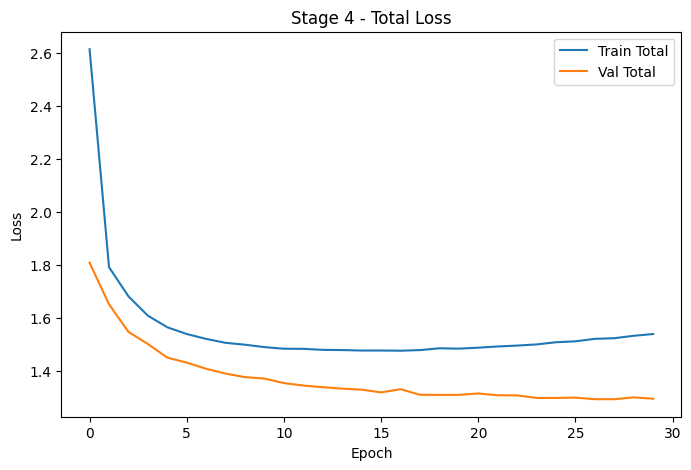

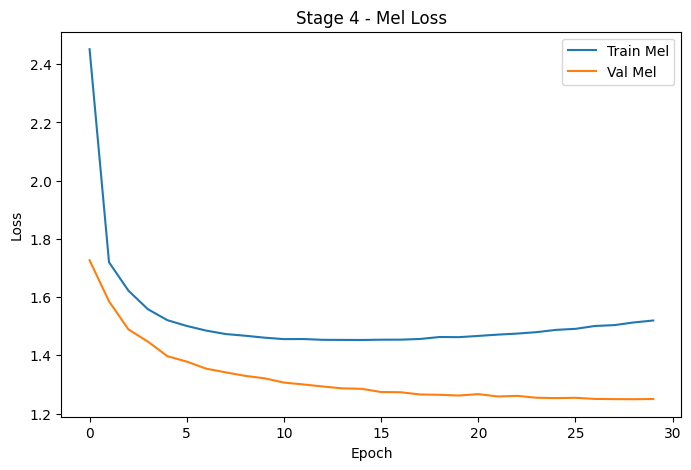

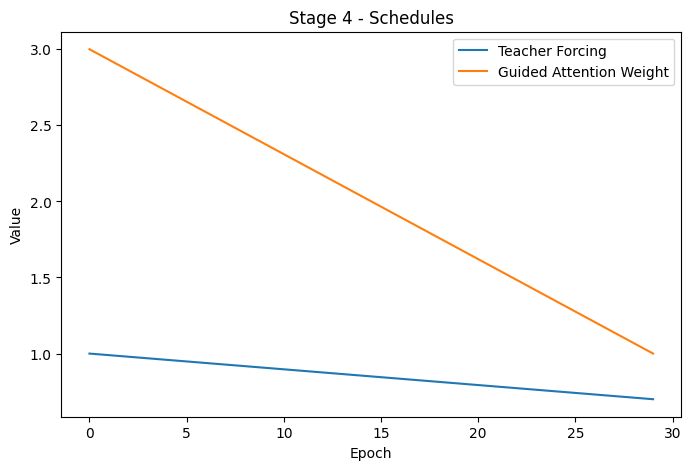

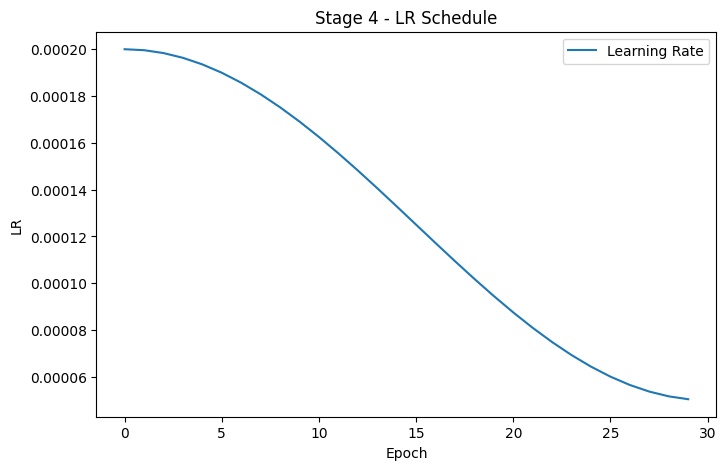

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_total"], label="Train Total")
plt.plot(history["val_total"], label="Val Total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 4 - Total Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_mel"], label="Train Mel")
plt.plot(history["val_mel"], label="Val Mel")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 4 - Mel Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["teacher_forcing"], label="Teacher Forcing")
plt.plot(history["attn_lambda"], label="Guided Attention Weight")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Stage 4 - Schedules")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["lr"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Stage 4 - LR Schedule")
plt.legend()
plt.show()

In [19]:
test_text = "hello how are you today"

result = synthesize_mel(
    model,
    test_text,
    max_steps=280,
    stop_threshold=0.35,
    min_decoder_steps=10
)

print("Phoneme sequence:")
print(result["phonemes"])

audio = mel_to_audio_griffinlim(result["mel_post"])
out_path = os.path.join(WORKING_DIR, "stage4_tts_test.wav")
sf.write(out_path, audio, SAMPLE_RATE)

print("Saved:", out_path)
print("Audio length (sec):", len(audio) / SAMPLE_RATE)

Phoneme sequence:
hello how are you today
Saved: /kaggle/working/stage4_tts_test.wav
Audio length (sec): 1.3583673469387756


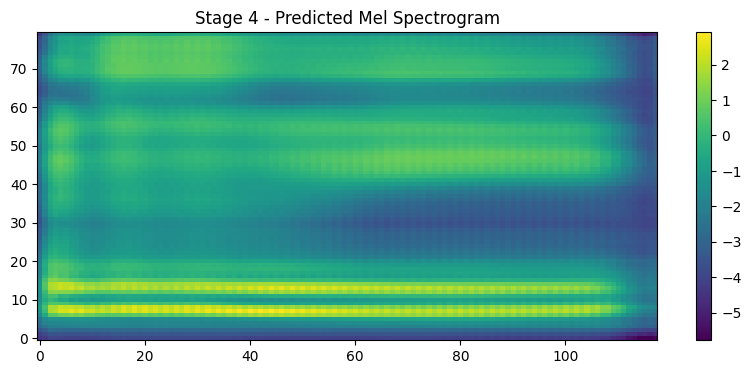

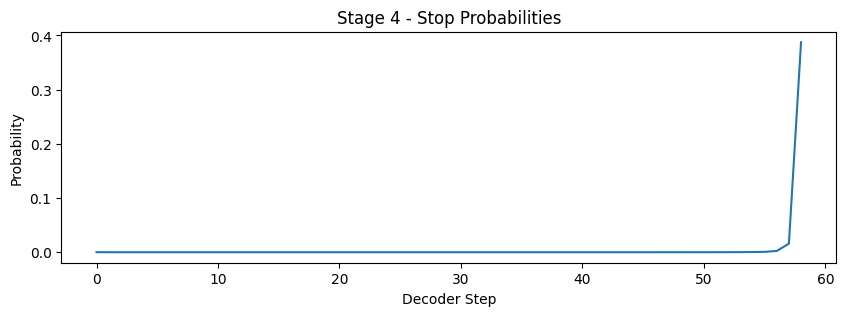

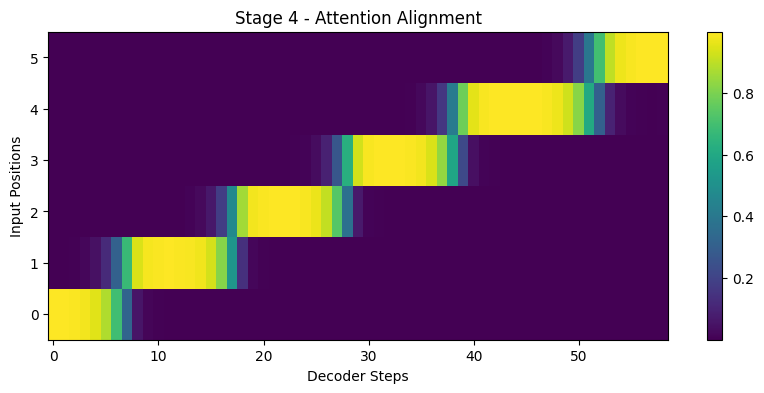

In [20]:
plt.figure(figsize=(10, 4))
plt.imshow(result["mel_post"], aspect="auto", origin="lower")
plt.title("Stage 4 - Predicted Mel Spectrogram")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(result["stop_probs"])
plt.title("Stage 4 - Stop Probabilities")
plt.xlabel("Decoder Step")
plt.ylabel("Probability")
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(result["attn"].T, aspect="auto", origin="lower")
plt.title("Stage 4 - Attention Alignment")
plt.xlabel("Decoder Steps")
plt.ylabel("Input Positions")
plt.colorbar()
plt.show()

In [21]:
Audio(out_path)

**stage 5**

In [1]:
!pip -q install unidecode librosa soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 6.1 MB/s eta 0:00:0000:01


In [2]:
import os
import re
import gc
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
import librosa
import soundfile as sf

from IPython.display import Audio

In [3]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi
else:
    print("Enable GPU from Kaggle: Settings -> Accelerator -> GPU")

CUDA available: True
GPU: Tesla T4
Tue Mar 24 23:10:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

WORKING_DIR = "/kaggle/working"
CKPT_DIR = os.path.join(WORKING_DIR, "vocoder_checkpoints_stage5")
SAMPLES_DIR = os.path.join(WORKING_DIR, "vocoder_samples_stage5")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)

candidate_roots = []
for root, dirs, files in os.walk("/kaggle/input"):
    if "metadata.csv" in files and "wavs" in dirs:
        candidate_roots.append(root)

if len(candidate_roots) == 0:
    raise FileNotFoundError(
        "Could not find LJSpeech under /kaggle/input. "
        "Please attach the dataset rahulbhalley/ljspeech11 first."
    )

print("Found dataset candidates:")
for p in candidate_roots:
    print(" -", p)

LJSPEECH_PATH = candidate_roots[0]
CSV_PATH = os.path.join(LJSPEECH_PATH, "metadata.csv")
WAVS_DIR = os.path.join(LJSPEECH_PATH, "wavs")

print("\nUsing:", LJSPEECH_PATH)

# Audio / mel config
SAMPLE_RATE = 22050
N_FFT = 1024
HOP_LENGTH = 256
WIN_LENGTH = 1024
N_MELS = 80

# Vocoder training segment
SEGMENT_MELS = 32
SEGMENT_SAMPLES = SEGMENT_MELS * HOP_LENGTH   # 8192 samples
MU_LAW_CHANNELS = 256

# Model config
AUDIO_EMBED_DIM = 64
MEL_DIM = 80
MEL_PROJ_DIM = 64
RNN_HIDDEN = 256
RNN_LAYERS = 2

# Training config
BATCH_SIZE = 12
EPOCHS = 20
LR = 2e-4
MIN_LR = 5e-5

MAX_MEL_LEN = 500
USE_MIXED_PRECISION = torch.cuda.is_available()
NUM_WORKERS = 0
EARLY_STOPPING_PATIENCE = 5
GRAD_CLIP = 1.0

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore")

Device: cuda
Found dataset candidates:
 - /kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1

Using: /kaggle/input/datasets/rahulbhalley/ljspeech11/LJSpeech-1.1


In [5]:
metadata = pd.read_csv(CSV_PATH, sep="|", header=None, names=["id", "raw_text", "normalized"])
metadata = metadata.reset_index(drop=True)
print("Dataset size:", len(metadata))
metadata.head()

Dataset size: 13100


,id,raw_text,normalized
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


In [6]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=1.0
)

def load_wav(path):
    wav, sr = torchaudio.load(path)
    wav = wav.mean(dim=0)
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    wav = torch.clamp(wav, -1.0, 1.0)
    return wav

def wav_to_mel(wav):
    mel = mel_transform(wav)
    mel = torch.log(torch.clamp(mel, min=1e-5))
    return mel.transpose(0, 1)  # [T, n_mels]

def mu_law_encode(audio, quantization_channels=256):
    mu = quantization_channels - 1
    audio = torch.clamp(audio, -1.0, 1.0)
    magnitude = torch.log1p(mu * torch.abs(audio)) / math.log1p(mu)
    signal = torch.sign(audio) * magnitude
    encoded = ((signal + 1) / 2 * mu + 0.5).long()
    return encoded

def mu_law_decode(encoded, quantization_channels=256):
    mu = quantization_channels - 1
    signal = 2 * (encoded.float() / mu) - 1
    magnitude = (1 / mu) * ((1 + mu) ** torch.abs(signal) - 1)
    audio = torch.sign(signal) * magnitude
    return audio

def get_approx_mel_len(wav_path):
    wav = load_wav(wav_path)
    return math.ceil(len(wav) / HOP_LENGTH)

In [7]:
keep_rows = []
for i, row in metadata.iterrows():
    wav_path = os.path.join(WAVS_DIR, row["id"] + ".wav")
    approx_mel_len = get_approx_mel_len(wav_path)
    if approx_mel_len >= SEGMENT_MELS and approx_mel_len <= MAX_MEL_LEN:
        keep_rows.append(i)

metadata = metadata.iloc[keep_rows].reset_index(drop=True)

# keep a manageable subset first
metadata = metadata.sample(n=min(6000, len(metadata)), random_state=42).reset_index(drop=True)

print("Usable vocoder dataset size:", len(metadata))
metadata.head()

Usable vocoder dataset size: 4656


,id,raw_text,normalized
0,LJ005-0158,"Bedding and clothing was still denied, but onl...","Bedding and clothing was still denied, but onl..."
1,LJ028-0209,On the sixteenth day the troops of Cyrus enter...,On the sixteenth day the troops of Cyrus enter...
2,LJ001-0095,"These and similar founts, cast by the above fi...","These and similar founts, cast by the above fi..."
3,LJ008-0281,"They found at Newgate, under disgraceful condi...","They found at Newgate, under disgraceful condi..."
4,LJ015-0036,"The bank was already insolvent,","The bank was already insolvent,"


In [8]:
indices = list(range(len(metadata)))
random.shuffle(indices)

split = int(0.95 * len(indices))
train_idx = indices[:split]
val_idx = indices[split:]

train_df = metadata.iloc[train_idx].reset_index(drop=True)
val_df = metadata.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 4423
Val: 233


In [10]:
class VocoderDataset(Dataset):
    def __init__(self, df, segment_mels=32):
        self.df = df.reset_index(drop=True)
        self.segment_mels = segment_mels
        self.segment_samples = segment_mels * HOP_LENGTH

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav_path = os.path.join(WAVS_DIR, row["id"] + ".wav")

        wav = load_wav(wav_path)
        mel = wav_to_mel(wav)  # [T_mel, 80]

        total_mels = mel.size(0)

        if total_mels <= self.segment_mels:
            start_mel = 0
        else:
            start_mel = random.randint(0, total_mels - self.segment_mels)

        end_mel = start_mel + self.segment_mels
        mel_seg = mel[start_mel:end_mel]  # [segment_mels, 80]

        start_sample = start_mel * HOP_LENGTH
        end_sample = start_sample + self.segment_samples
        wav_seg = wav[start_sample:end_sample]

        if len(wav_seg) < self.segment_samples:
            pad = self.segment_samples - len(wav_seg)
            wav_seg = F.pad(wav_seg, (0, pad))

        target_classes = mu_law_encode(wav_seg, MU_LAW_CHANNELS)  # [segment_samples]

        # autoregressive input = shifted target
        input_classes = torch.zeros_like(target_classes)
        input_classes[1:] = target_classes[:-1]

        return (
            mel_seg.float(),                 # [segment_mels, 80]
            input_classes.long(),            # [segment_samples]
            target_classes.long()            # [segment_samples]
        )

train_ds = VocoderDataset(train_df, segment_mels=SEGMENT_MELS)
val_ds = VocoderDataset(val_df, segment_mels=SEGMENT_MELS)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

sample_batch = next(iter(train_loader))
for item in sample_batch:
    print(item.shape)

torch.Size([12, 32, 80])
torch.Size([12, 8192])
torch.Size([12, 8192])


In [16]:
class SimpleWaveRNNVocoder(nn.Module):
    def __init__(
        self,
        n_classes=256,
        audio_embed_dim=64,
        mel_dim=80,
        mel_proj_dim=64,
        rnn_hidden=256,
        rnn_layers=2
    ):
        super().__init__()

        self.n_classes = n_classes
        self.audio_embedding = nn.Embedding(n_classes, audio_embed_dim)

        self.mel_proj = nn.Sequential(
            nn.Linear(mel_dim, mel_proj_dim),
            nn.ReLU(),
            nn.Linear(mel_proj_dim, mel_proj_dim),
            nn.ReLU()
        )

        self.input_proj = nn.Linear(audio_embed_dim + mel_proj_dim, rnn_hidden)

        self.gru = nn.GRU(
            input_size=rnn_hidden,
            hidden_size=rnn_hidden,
            num_layers=rnn_layers,
            batch_first=True
        )

        self.fc1 = nn.Linear(rnn_hidden, rnn_hidden)
        self.fc2 = nn.Linear(rnn_hidden, n_classes)

    def upsample_mel(self, mel):
        # mel: [B, T_mel, mel_dim]
        # repeat each mel frame HOP_LENGTH times
        mel_up = mel.repeat_interleave(HOP_LENGTH, dim=1)  # [B, T_audio, mel_dim]
        return mel_up

    def forward(self, mel, audio_input_classes):
        # mel: [B, T_mel, 80]
        # audio_input_classes: [B, T_audio]

        mel_up = self.upsample_mel(mel)                          # [B, T_audio, 80]
        mel_feat = self.mel_proj(mel_up)                        # [B, T_audio, mel_proj_dim]

        audio_emb = self.audio_embedding(audio_input_classes)   # [B, T_audio, audio_embed_dim]

        x = torch.cat([audio_emb, mel_feat], dim=-1)
        x = self.input_proj(x)
        x = torch.relu(x)

        x, _ = self.gru(x)
        x = torch.relu(self.fc1(x))
        logits = self.fc2(x)                                    # [B, T_audio, 256]

        return logits

In [17]:
model = SimpleWaveRNNVocoder(
    n_classes=MU_LAW_CHANNELS,
    audio_embed_dim=AUDIO_EMBED_DIM,
    mel_dim=MEL_DIM,
    mel_proj_dim=MEL_PROJ_DIM,
    rnn_hidden=RNN_HIDDEN,
    rnn_layers=RNN_LAYERS
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=MIN_LR)
scaler = torch.amp.GradScaler("cuda", enabled=USE_MIXED_PRECISION)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", num_params)

Trainable params: 979840


In [18]:
def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, train_loss, val_loss):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "train_loss": train_loss,
        "val_loss": val_loss
    }, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None, map_location=device):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
    if scaler is not None and ckpt.get("scaler_state") is not None:
        scaler.load_state_dict(ckpt["scaler_state"])
    return ckpt

In [19]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for mel, audio_in, audio_target in loader:
            mel = mel.to(device, non_blocking=True)
            audio_in = audio_in.to(device, non_blocking=True)
            audio_target = audio_target.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
                logits = model(mel, audio_in)
                loss = F.cross_entropy(
                    logits.reshape(-1, MU_LAW_CHANNELS),
                    audio_target.reshape(-1)
                )

            bs = mel.size(0)
            total_loss += loss.item() * bs
            total_items += bs

    return total_loss / total_items

In [20]:
@torch.no_grad()
def vocode_from_mel(model, mel, max_samples=None):
    """
    mel: torch tensor [T_mel, 80]
    returns waveform tensor [T_audio]
    """
    model.eval()

    if mel.dim() == 2:
        mel = mel.unsqueeze(0)

    mel = mel.to(device)
    T_audio = mel.size(1) * HOP_LENGTH

    if max_samples is not None:
        T_audio = min(T_audio, max_samples)

    generated = torch.zeros((1, T_audio), dtype=torch.long, device=device)

    for t in range(T_audio):
        with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
            logits = model(mel, generated)   # [1, T_audio, 256]
            next_logits = logits[:, t, :]
            next_sample = torch.argmax(next_logits, dim=-1)

        generated[:, t] = next_sample

        if t % 1000 == 0 and t > 0:
            pass

    audio = mu_law_decode(generated.squeeze(0).cpu(), MU_LAW_CHANNELS)
    return audio

@torch.no_grad()
def save_val_sample(model, epoch, val_df):
    row = val_df.iloc[0]
    wav_path = os.path.join(WAVS_DIR, row["id"] + ".wav")

    wav = load_wav(wav_path)
    mel = wav_to_mel(wav)

    # use short portion to keep inference reasonable
    mel = mel[:SEGMENT_MELS]

    audio = vocode_from_mel(model, mel, max_samples=SEGMENT_SAMPLES)
    out_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:02d}_gtmel.wav")
    sf.write(out_path, audio.numpy(), SAMPLE_RATE)

    plt.figure(figsize=(10, 4))
    plt.imshow(mel.cpu().numpy().T, aspect="auto", origin="lower")
    plt.title(f"Ground-Truth Mel Segment - Epoch {epoch}")
    plt.colorbar()
    plt.tight_layout()
    plot_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:02d}_gtmel.png")
    plt.savefig(plot_path)
    plt.close()

    print("Saved validation vocoder sample:", out_path)
    print("Saved mel plot:", plot_path)

In [ ]:
best_val = float("inf")
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "lr": []
}

for epoch in range(1, EPOCHS + 1):
    model.train()

    train_loss_sum = 0.0
    total_items = 0

    for mel, audio_in, audio_target in train_loader:
        mel = mel.to(device, non_blocking=True)
        audio_in = audio_in.to(device, non_blocking=True)
        audio_target = audio_target.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=USE_MIXED_PRECISION):
            logits = model(mel, audio_in)
            loss = F.cross_entropy(
                logits.reshape(-1, MU_LAW_CHANNELS),
                audio_target.reshape(-1)
            )

        if not torch.isfinite(loss):
            print("Skipping batch because loss is NaN/Inf")
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        bs = mel.size(0)
        train_loss_sum += loss.item() * bs
        total_items += bs

    if total_items == 0:
        raise RuntimeError("No valid training batches were processed.")

    train_loss = train_loss_sum / total_items
    val_loss = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch:02d} | "
        f"LR {optimizer.param_groups[0]['lr']:.6f} | "
        f"Train Loss {train_loss:.4f} | "
        f"Val Loss {val_loss:.4f}"
    )

    latest_path = os.path.join(CKPT_DIR, "latest_checkpoint.pt")
    save_checkpoint(latest_path, model, optimizer, scheduler, scaler, epoch, train_loss, val_loss)

    if val_loss < best_val:
        best_val = val_loss
        epochs_without_improvement = 0

        best_path = os.path.join(CKPT_DIR, "best_checkpoint.pt")
        save_checkpoint(best_path, model, optimizer, scheduler, scaler, epoch, train_loss, val_loss)
        print("Saved best checkpoint.")

        try:
            save_val_sample(model, epoch, val_df)
        except Exception as e:
            print("Could not save validation sample:", e)
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    scheduler.step()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

best_path = os.path.join(CKPT_DIR, "best_checkpoint.pt")
if os.path.exists(best_path):
    ckpt = load_checkpoint(best_path, model, optimizer=None, scheduler=None, scaler=None)
    print("Restored best checkpoint from epoch:", ckpt["epoch"])

Epoch 01 | LR 0.000200 | Train Loss 4.2722 | Val Loss 3.4297
Saved best checkpoint.
Saved validation vocoder sample: /kaggle/working/vocoder_samples_stage5/epoch_01_gtmel.wav
Saved mel plot: /kaggle/working/vocoder_samples_stage5/epoch_01_gtmel.png
Epoch 02 | LR 0.000199 | Train Loss 3.1967 | Val Loss 3.0366
Saved best checkpoint.
Saved validation vocoder sample: /kaggle/working/vocoder_samples_stage5/epoch_02_gtmel.wav
Saved mel plot: /kaggle/working/vocoder_samples_stage5/epoch_02_gtmel.png
Epoch 03 | LR 0.000196 | Train Loss 2.9669 | Val Loss 2.9100
Saved best checkpoint.
Saved validation vocoder sample: /kaggle/working/vocoder_samples_stage5/epoch_03_gtmel.wav
Saved mel plot: /kaggle/working/vocoder_samples_stage5/epoch_03_gtmel.png
Epoch 04 | LR 0.000192 | Train Loss 2.8563 | Val Loss 2.8083
Saved best checkpoint.
Saved validation vocoder sample: /kaggle/working/vocoder_samples_stage5/epoch_04_gtmel.wav
Saved mel plot: /kaggle/working/vocoder_samples_stage5/epoch_04_gtmel.png
Epoc

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")
plt.title("Stage 5 Vocoder - Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["lr"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Stage 5 Vocoder - LR Schedule")
plt.legend()
plt.show()

In [ ]:
row = val_df.iloc[0]
wav_path = os.path.join(WAVS_DIR, row["id"] + ".wav")

wav = load_wav(wav_path)
mel = wav_to_mel(wav)

mel_short = mel[:SEGMENT_MELS]
audio_pred = vocode_from_mel(model, mel_short, max_samples=SEGMENT_SAMPLES)

gt_out = os.path.join(WORKING_DIR, "stage5_gtmel_vocoder.wav")
sf.write(gt_out, audio_pred.numpy(), SAMPLE_RATE)

print("Saved:", gt_out)
print("Audio length (sec):", len(audio_pred) / SAMPLE_RATE)

In [ ]:
Audio(gt_out)